In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append("/home/sambt/CASE_final/CASE_QUAK_final/commonTools/")
import helper_functions as hf
import qRegNN_NFs_general as qrnn
#import qRegNN_NFs_general_allInOne as qrnn2
import sklearn
import scipy
import sklearn.datasets as datasets
import h5py
import os
import pandas as pd
import corner
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
sys.path.append("/home/sambt/SINF/")
sys.path.append("/home/sambt/SINF/sinf/")
from GIS import GIS
import torch
import torch.nn as nn
device = torch.device('cuda:0')
import uproot
from tqdm import tqdm
import h5py

# Load data

In [2]:
base = "/nobackup/users/sambt/QR_samples/LHCO/"
f_bb1 = f"{base}/challenge/BB1/merged.h5"
f_ind_bb1 = f"{base}/challenge/BB1/split_indices.h5"
f_rd = f"{base}/rd/RD/merged.h5"
f_ind_rd = f"{base}/rd/RD/split_indices.h5"
f_ind_rd_sig = f"{base}/rd/RD/sig_split_indices.h5"
f_zxy = f"{base}/rd/ZXY/merged.h5"

fitvars = ['jet1_rho','jet1_tau21','jet1_tau32','jet1_tau43',
           'jet2_rho','jet2_tau21','jet2_tau32','jet2_tau43']

fitvarNames = [r"Jet 1 $\rho$",r"Jet 1 $\tau_{21}$",r"Jet 1 $\tau_{32}$",r"Jet 1 $\tau_{43}$",
               r"Jet 2 $\rho$",r"Jet 2 $\tau_{21}$",r"Jet 2 $\tau_{32}$",r"Jet 2 $\tau_{43}$"]

with h5py.File(f_ind_rd,'r') as f:
    rd_test_idx = f['test_inds'][()]
    rd_val_idx = f['val_inds'][()]
    
with h5py.File(f_ind_rd_sig,'r') as f:
    rd_sig_train_idx = f['train_inds'][()]
    rd_sig_test_idx = f['test_inds'][()]
    rd_sig_val_idx = f['val_inds'][()]
    
with h5py.File(f_ind_bb1,'r') as f:
    bb1_test_idx = f['test_inds'][()]
    bb1_val_idx = f['val_inds'][()]
    
with h5py.File(f_bb1,"r") as fp_b1:
    labels_b1 = np.loadtxt(f"{base}/challenge/BB1/events_LHCO2020_BlackBox1.masterkey")
    b1_test = np.concatenate([fp_b1[v][()][labels_b1==0].reshape(-1,1) for v in fitvars],axis=1)[bb1_test_idx]
    b1_val = np.concatenate([fp_b1[v][()][labels_b1==0].reshape(-1,1) for v in fitvars],axis=1)[bb1_val_idx]
    b1_sig = np.concatenate([fp_b1[v][()][labels_b1==1].reshape(-1,1) for v in fitvars],axis=1)
    
with h5py.File(f_rd,"r") as frd:
    label = frd['label'][()]
    mask = label==0
    rd_test = np.concatenate([frd[v][()][mask].reshape(-1,1) for v in fitvars],axis=1)[rd_test_idx]
    rd_val = np.concatenate([frd[v][()][mask].reshape(-1,1) for v in fitvars],axis=1)[rd_val_idx]
    rd_sig = np.concatenate([frd[v][()][~mask].reshape(-1,1) for v in fitvars],axis=1)

######
b1 = np.concatenate((b1_test,b1_val),axis=0)
rd = np.concatenate((rd_test,rd_val),axis=0)

# run corrections
model_dir = "LHCO_BB1toPythRD_jets12"
corrector = qrnn.chainedNFCorrector(f"NF_models_QR_general/{model_dir}/")
corr_b1 = corrector.correctFull(b1)
corr_b1 = np.concatenate([corr_b1[v] for v in fitvars],axis=1)
corr_rd = corrector.invertFull(rd)
corr_rd = np.concatenate([corr_rd[v] for v in fitvars],axis=1)


# make train/test/val splits
rng1 = 42109
rng2 = 24513

b1_train, b1_test = train_test_split(b1,train_size=0.5,random_state=rng1)
b1_test, b1_val = train_test_split(b1_test,train_size=0.5,random_state=rng2)

rd_train, rd_test = train_test_split(rd,train_size=0.5,random_state=rng1)
rd_test, rd_val = train_test_split(rd_test,train_size=0.5,random_state=rng2)

corr_b1_train, corr_b1_test = train_test_split(corr_b1,train_size=0.5,random_state=rng1)
corr_b1_test, corr_b1_val = train_test_split(corr_b1_test,train_size=0.5,random_state=rng2)

corr_rd_train, corr_rd_test = train_test_split(corr_rd,train_size=0.5,random_state=rng1)
corr_rd_test, corr_rd_val = train_test_split(corr_rd_test,train_size=0.5,random_state=rng2)

rd_sig_train = rd_sig[rd_sig_train_idx]
rd_sig_test = rd_sig[rd_sig_test_idx]
rd_sig_val = rd_sig[rd_sig_val_idx]

######
corr_b1_all = np.concatenate((corr_b1_train,corr_b1_test,corr_b1_val),axis=0)
corr_rd_all = np.concatenate((corr_rd_train,corr_rd_test,corr_rd_val),axis=0)
b1_all = np.concatenate((b1_train,b1_test,b1_val),axis=0)
rd_all = np.concatenate((rd_train,rd_test,rd_val),axis=0)

[]


100%|██████████| 50/50 [00:02<00:00, 23.35it/s]


[0]


100%|██████████| 50/50 [00:01<00:00, 29.84it/s]


[0, 1]


...

100%|██████████| 51/51 [00:01<00:00, 30.13it/s]


[0]


100%|██████████| 51/51 [00:01<00:00, 29.90it/s]


[]


100%|██████████| 51/51 [00:01<00:00, 29.80it/s]


In [4]:
# write data to h5 file
outf = "/nobackup/users/sambt/QR_samples/LHCO/morphed_outputs/plotData.h5"
group = "BB1toRD"
dt = h5py.string_dtype(encoding='utf-8')
with h5py.File(outf,"a") as f:
    if group not in f.keys():
        f.create_group(group)
    f.create_dataset(f"{group}/rd",data=rd)
    f.create_dataset(f"{group}/bb1",data=b1)
    f.create_dataset(f"{group}/corr_rd",data=corr_rd)
    f.create_dataset(f"{group}/corr_bb1",data=corr_b1)
    f.create_dataset(f"{group}/rd_sig",data=rd_sig)
    f.create_dataset(f"{group}/rd_sig_train_idx",data=rd_sig_train_idx)
    f.create_dataset(f"{group}/rd_sig_test_idx",data=rd_sig_test_idx)
    f.create_dataset(f"{group}/rd_sig_val_idx",data=rd_sig_val_idx)
    f.create_dataset(f"{group}/fitvars",data=np.array(fitvars,dtype=dt))

# Comparison plots, uncorrected

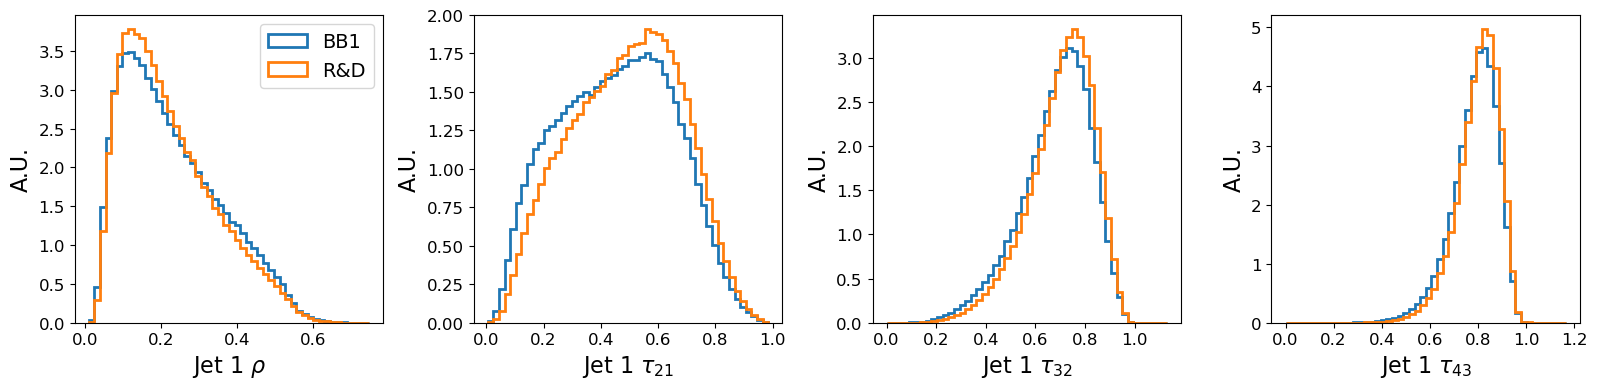

In [15]:
fig,axes = plt.subplots(1,4,figsize=(16,4))
for i in range(4):
    plt.sca(axes.flatten()[i])
    h,bins,_ = plt.hist(b1[:,i],bins=50,histtype='step',density=True,label='BB1',linewidth=2)
    h,bins,_ = plt.hist(rd[:,i],bins=bins,histtype='step',density=True,label='R&D',linewidth=2)
    plt.xlabel(fitvarNames[i],fontsize=16)
    plt.ylabel("A.U.",fontsize=16)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    if i==0:
        plt.legend(fontsize=14)
plt.tight_layout()
plt.savefig(f"NF_models_QR_general/{model_dir}/jet1_BB1vsRD_comparison.pdf")

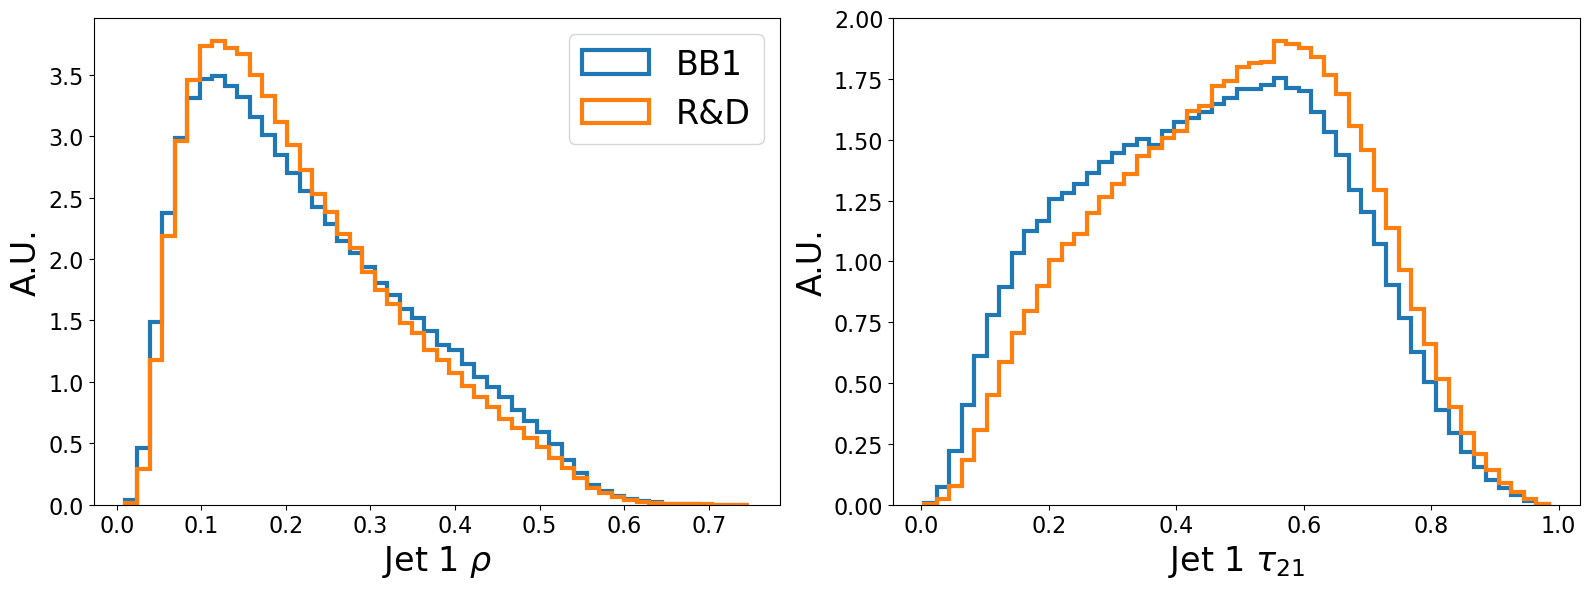

In [9]:
fig,axes = plt.subplots(1,2,figsize=(16,6))
for i in range(2):
    plt.sca(axes.flatten()[i])
    h,bins,_ = plt.hist(b1[:,i],bins=50,histtype='step',density=True,label='BB1',linewidth=3)
    h,bins,_ = plt.hist(rd[:,i],bins=bins,histtype='step',density=True,label='R&D',linewidth=3)
    plt.xlabel(fitvarNames[i],fontsize=24)
    plt.ylabel("A.U.",fontsize=24)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    if i==0:
        plt.legend(fontsize=24)
plt.tight_layout()
plt.savefig(f"NF_models_QR_general/{model_dir}/jet1_rho_tau21_comparison.pdf")

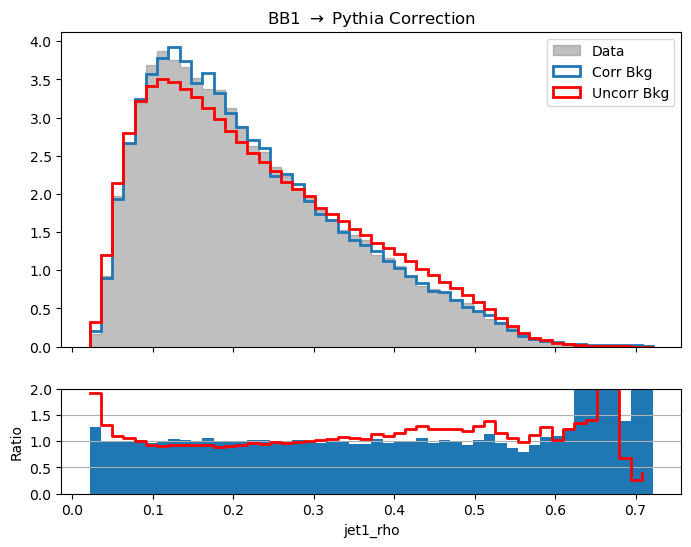

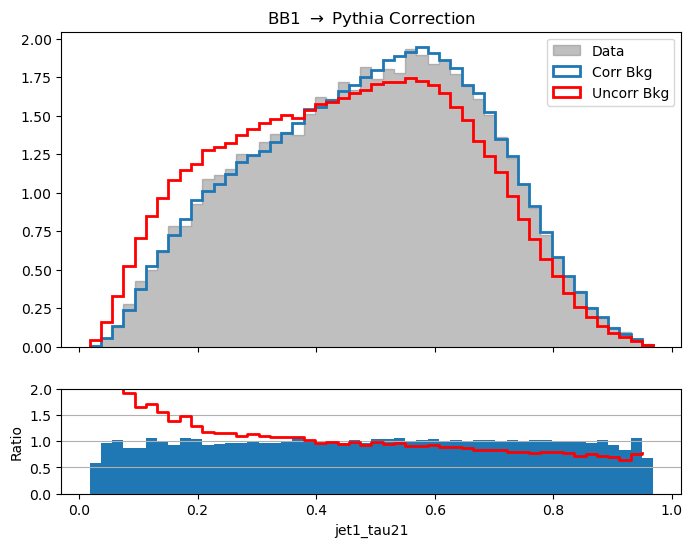

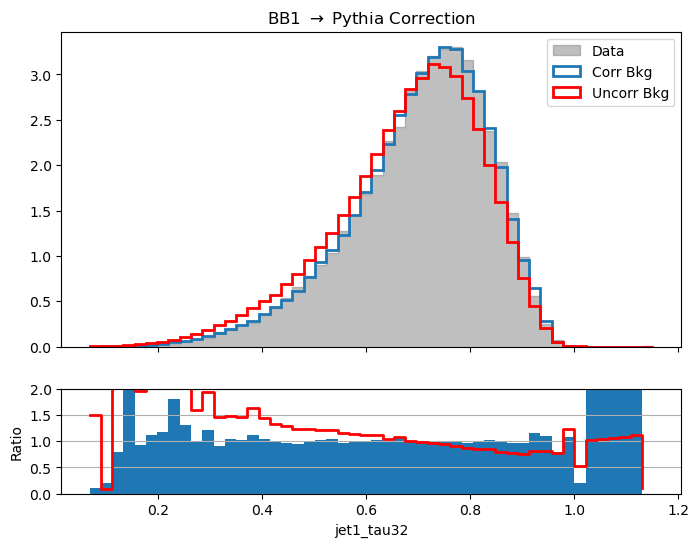

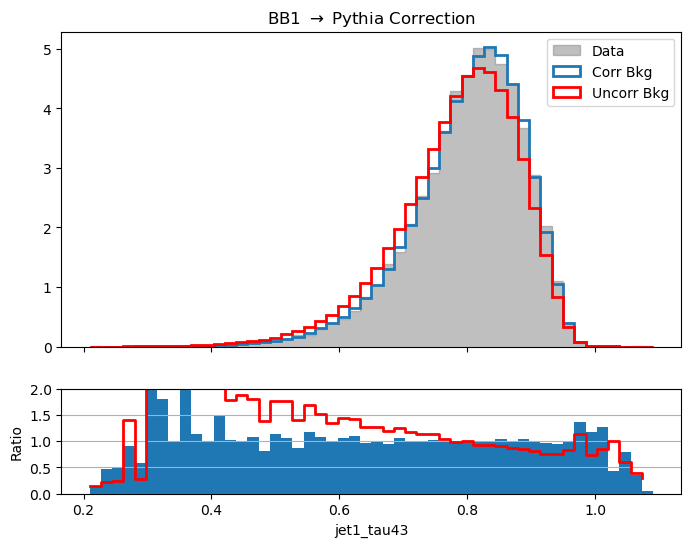

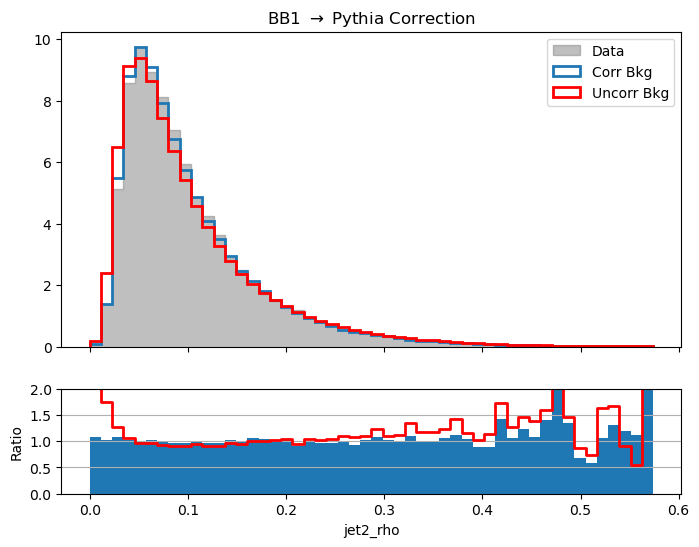

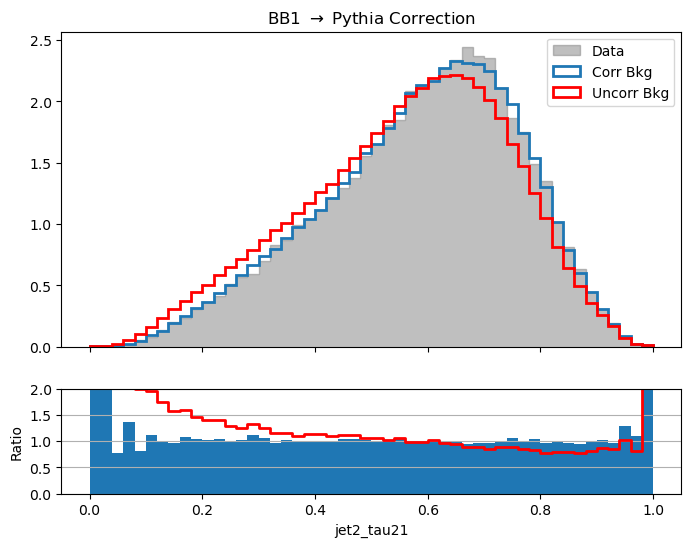

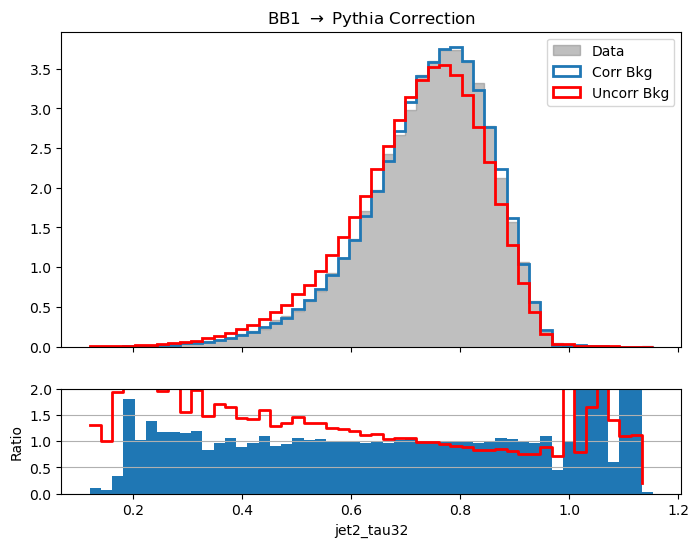

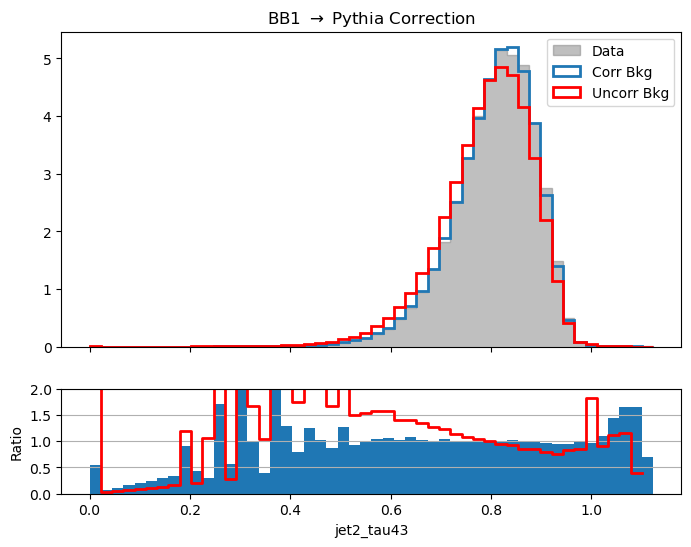

In [5]:
for i in range(len(fitvars)):
    qrnn.plotTriplet(rd_all[:,i],corr_b1_all[:,i],b1_all[:,i],50,fitvars[i],r"BB1 $\rightarrow$ Pythia Correction","",save=False,log=False,ylim=[0,2])

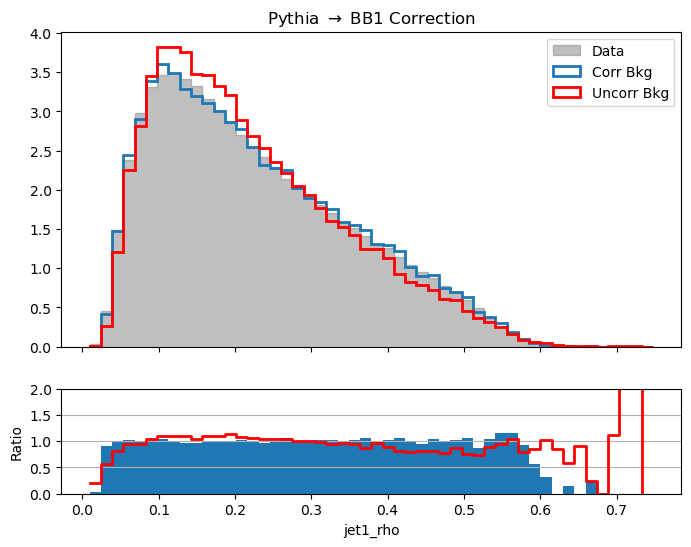

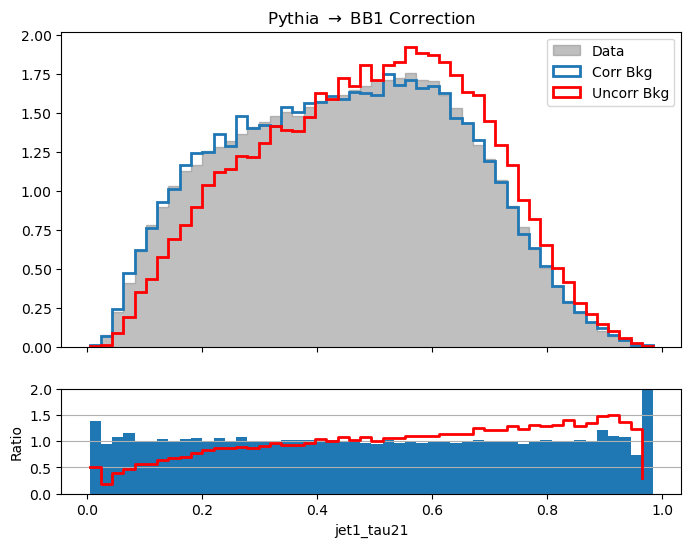

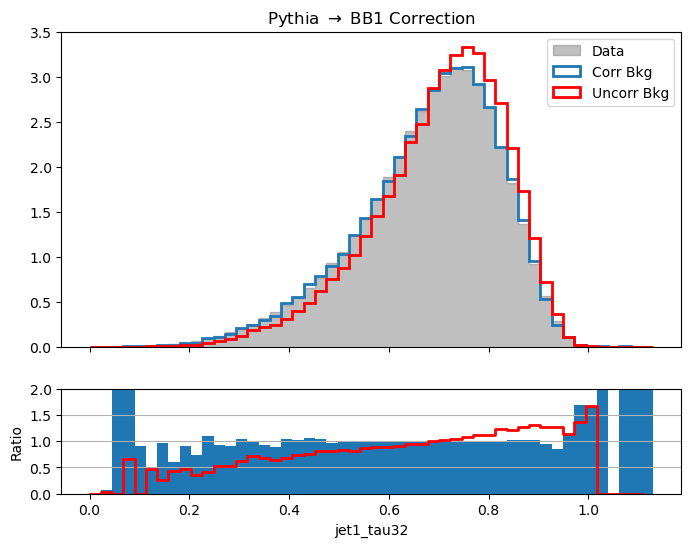

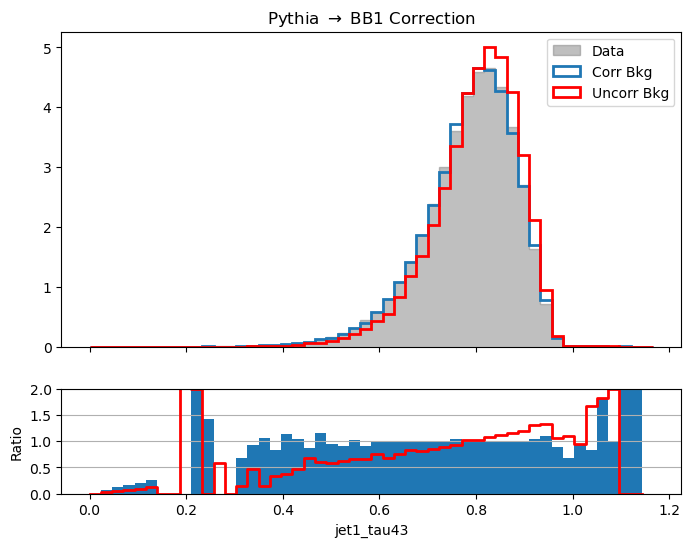

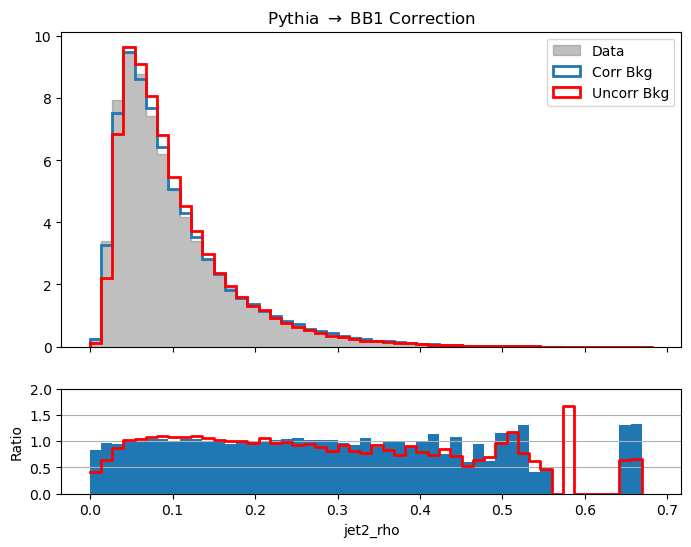

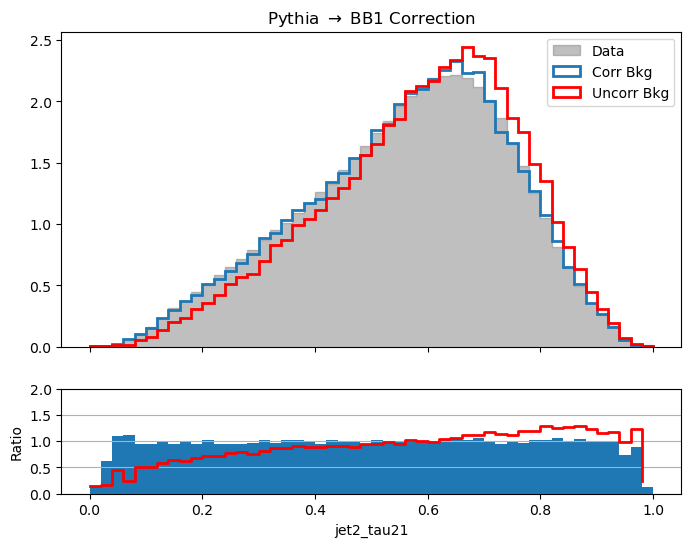

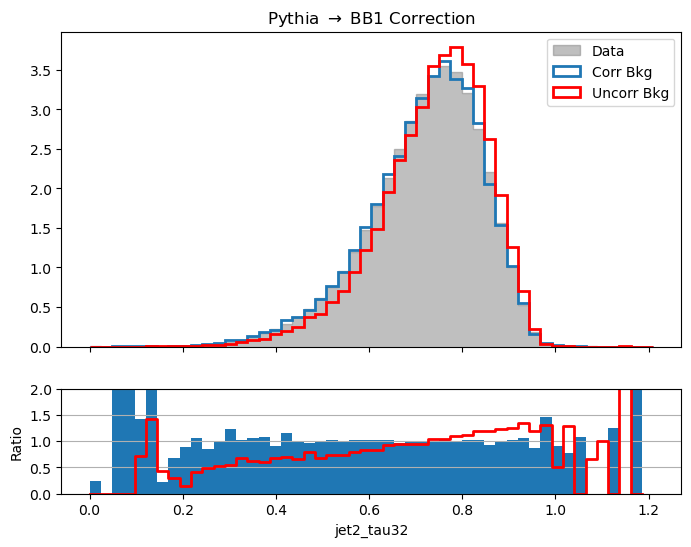

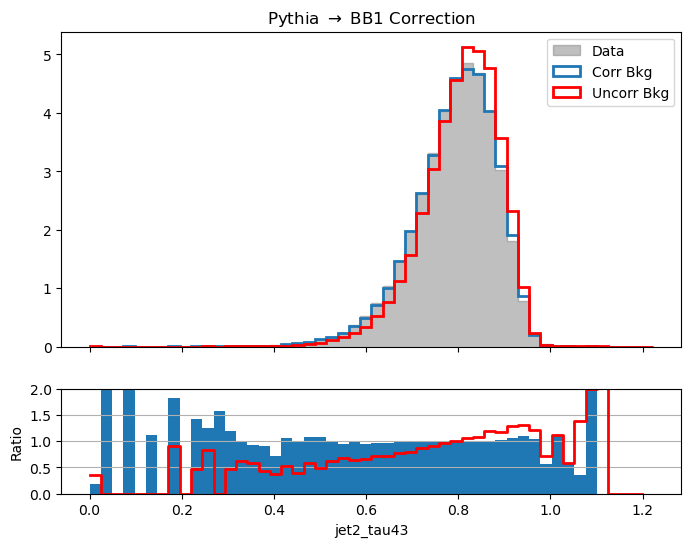

In [6]:
for i in range(len(fitvars)):
    qrnn.plotTriplet(b1_all[:,i],corr_rd_all[:,i],rd_all[:,i],50,fitvars[i],r"Pythia $\rightarrow$ BB1 Correction","",save=False,log=False,ylim=[0,2])

# Comparison Plots, R&D --> BB1

/home/sambt/.local/lib/python3.7/site-packages/ipykernel_launcher.py:20: UserWarning: FixedFormatter should only be used together with FixedLocator
/home/sambt/.local/lib/python3.7/site-packages/ipykernel_launcher.py:20: UserWarning: FixedFormatter should only be used together with FixedLocator
/home/sambt/.local/lib/python3.7/site-packages/ipykernel_launcher.py:20: UserWarning: FixedFormatter should only be used together with FixedLocator


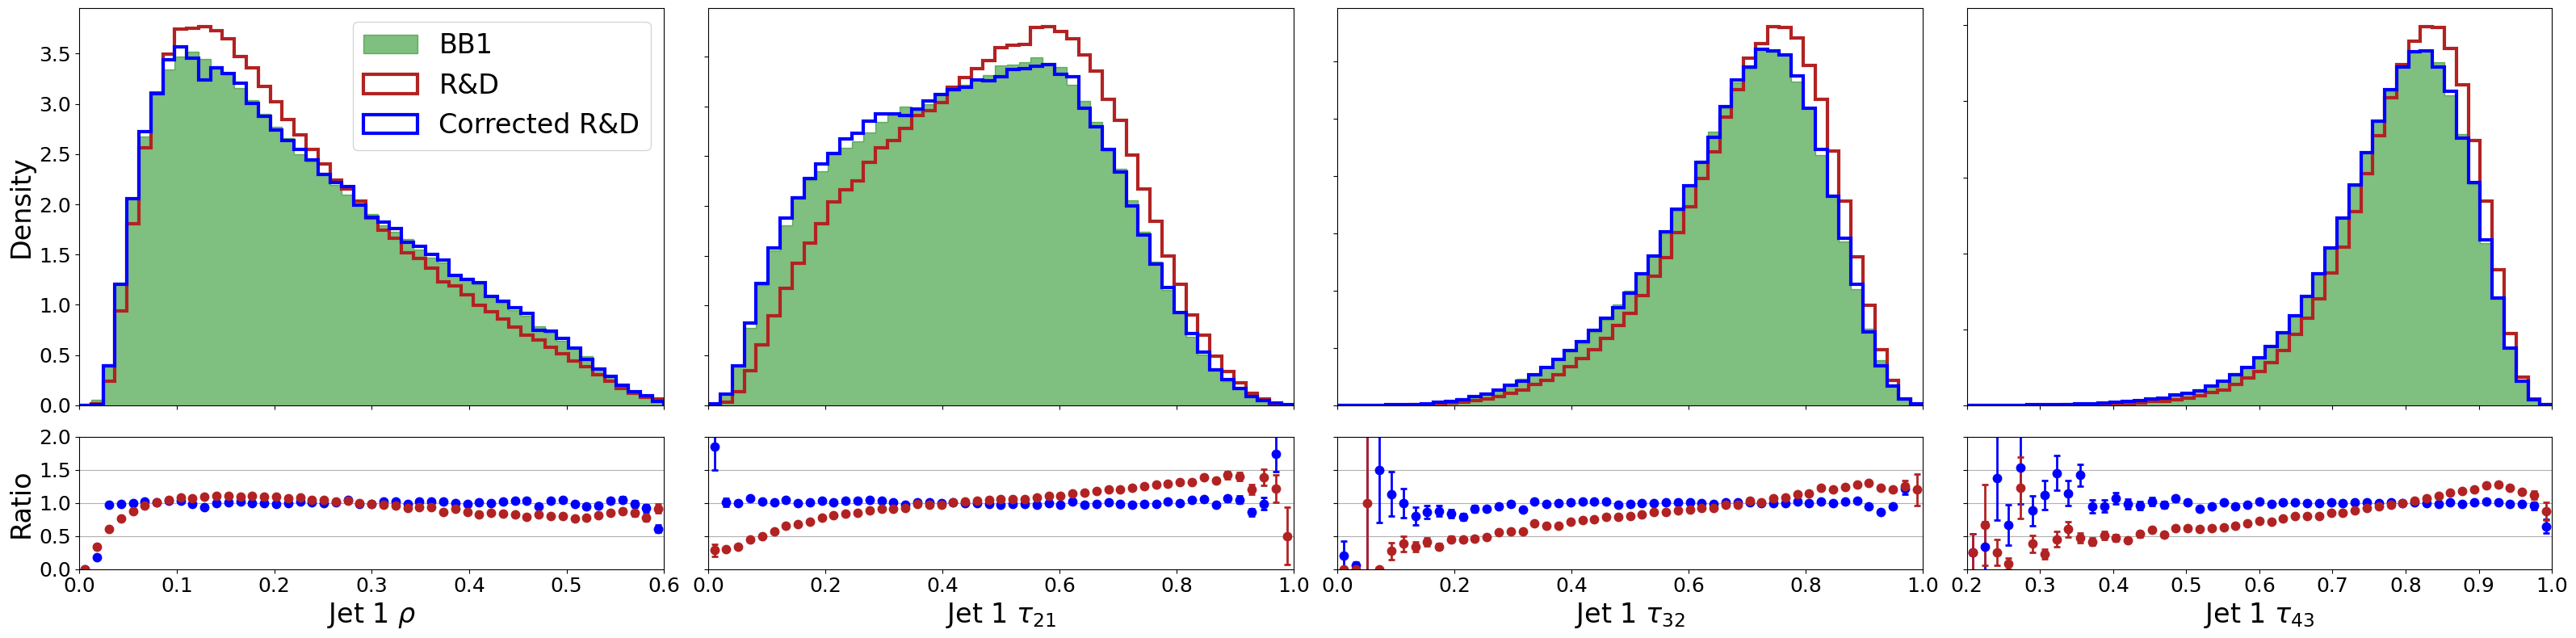

In [20]:
fig,axes = plt.subplots(figsize=(32,8),nrows=2,ncols=4,gridspec_kw={'height_ratios':[3,1]},sharex=False)
names = ['BB1','R&D','Corrected R&D']
colors = ['green','firebrick','blue']
xlims = [[0,0.6],[0,1],[0,1],[0.2,1]]
for i in range(4):
    ax = axes[:,i]
    xlim = xlims[i]
    bins = np.linspace(xlim[0],xlim[1],50)
    qrnn.triplet(b1_all[:,i],corr_rd_all[:,i],rd_all[:,i],ax,names,colors,bins=bins,xlim=xlim)
   
    plt.sca(ax[0])
    xt = plt.gca().get_xticks()
    xt = plt.xticks(xt,labels=len(xt)*[""])
    if i==0:
        plt.legend(loc='upper right',fontsize=24)
        plt.ylabel("Density",fontsize=24)
        yt = plt.yticks(fontsize=18)
    if i>0:
        yt = plt.gca().get_yticks()
        yt = plt.gca().set_yticklabels(len(yt)*[""])
        
    plt.sca(ax[1])
    plt.xlabel(fitvarNames[i],fontsize=24)
    xt = plt.xticks(fontsize=18)
    yt = plt.yticks(fontsize=18)
    if i==0:
        plt.ylabel("Ratio",fontsize=24)
    if i>0:
        yt = plt.gca().get_yticks()
        yt = plt.yticks(yt,labels=len(yt)*[""])
plt.subplots_adjust(wspace=0.08,hspace=0.15)
plt.tight_layout()
plt.savefig(f"NF_models_QR_general/{model_dir}/jet1_corrections_RDtoBB1.pdf")

/home/sambt/.local/lib/python3.7/site-packages/ipykernel_launcher.py:20: UserWarning: FixedFormatter should only be used together with FixedLocator
/home/sambt/.local/lib/python3.7/site-packages/ipykernel_launcher.py:20: UserWarning: FixedFormatter should only be used together with FixedLocator
/home/sambt/.local/lib/python3.7/site-packages/ipykernel_launcher.py:20: UserWarning: FixedFormatter should only be used together with FixedLocator


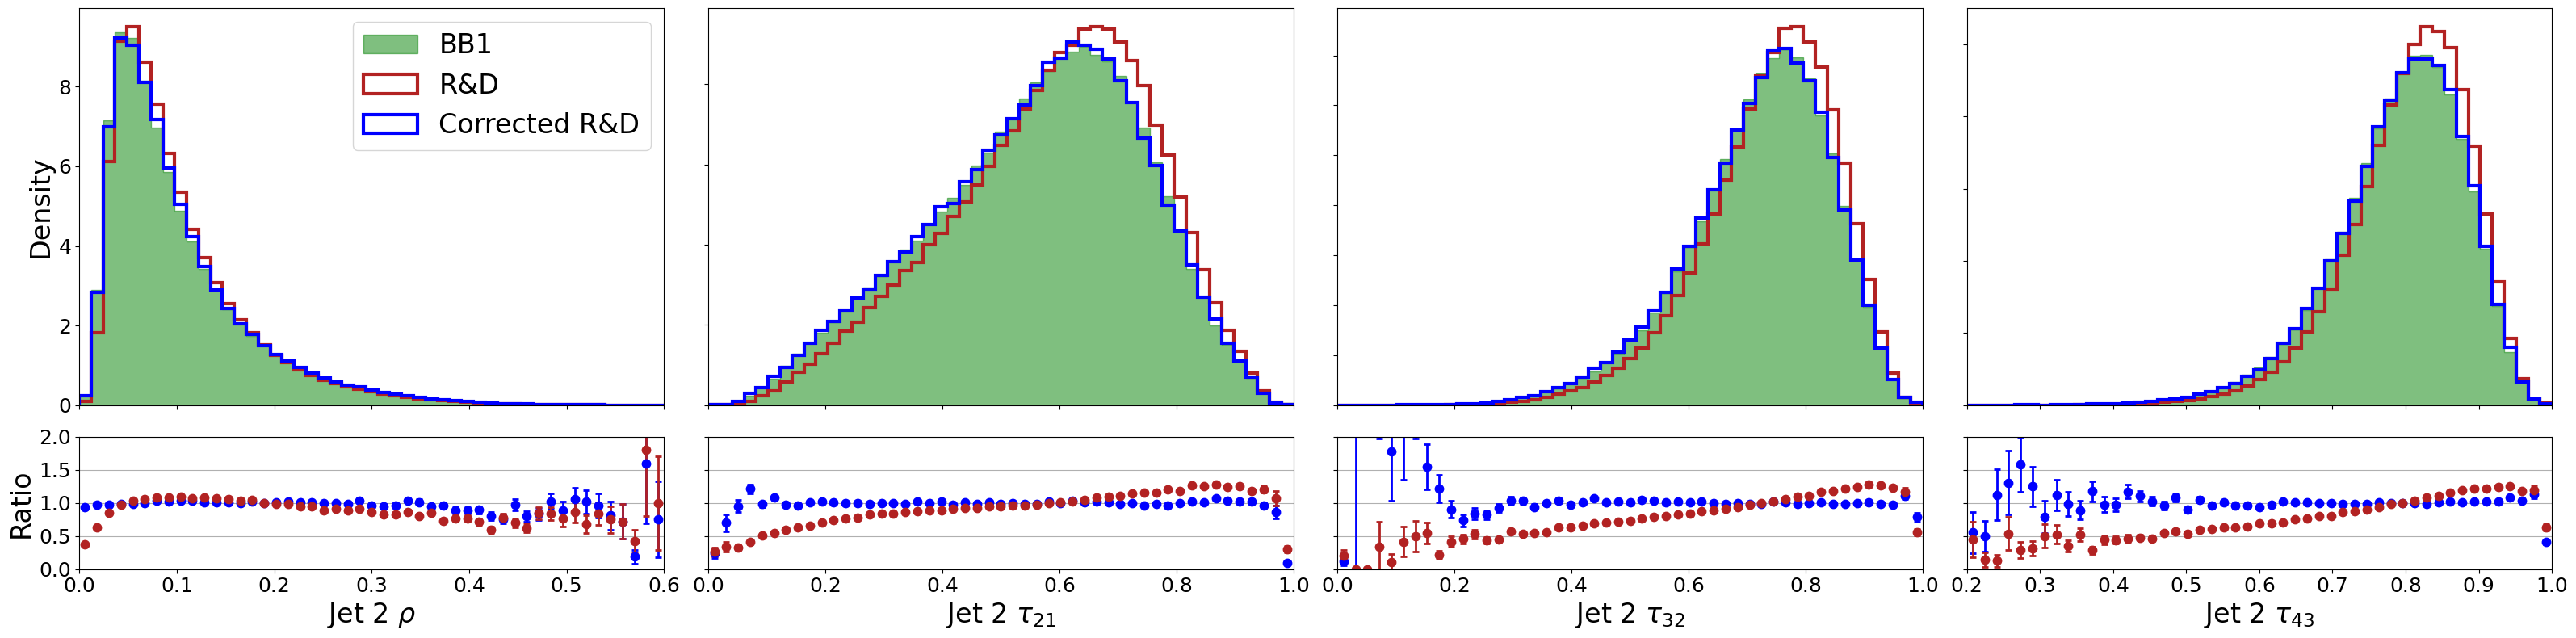

In [21]:
fig,axes = plt.subplots(figsize=(32,8),nrows=2,ncols=4,gridspec_kw={'height_ratios':[3,1]},sharex=False)
names = ['BB1','R&D','Corrected R&D']
colors = ['green','firebrick','blue']
xlims = [[0,0.6],[0,1],[0,1],[0.2,1]]
for i in range(4):
    ax = axes[:,i]
    xlim = xlims[i]
    bins = np.linspace(xlim[0],xlim[1],50)
    qrnn.triplet(b1_all[:,4+i],corr_rd_all[:,4+i],rd_all[:,4+i],ax,names,colors,bins=bins,xlim=xlim)
   
    plt.sca(ax[0])
    xt = plt.gca().get_xticks()
    xt = plt.xticks(xt,labels=len(xt)*[""])
    if i==0:
        plt.legend(loc='upper right',fontsize=24)
        plt.ylabel("Density",fontsize=24)
        yt = plt.yticks(fontsize=18)
    if i>0:
        yt = plt.gca().get_yticks()
        yt = plt.gca().set_yticklabels(len(yt)*[""])
        
    plt.sca(ax[1])
    plt.xlabel(fitvarNames[4+i],fontsize=24)
    xt = plt.xticks(fontsize=18)
    yt = plt.yticks(fontsize=18)
    if i==0:
        plt.ylabel("Ratio",fontsize=24)
    if i>0:
        yt = plt.gca().get_yticks()
        yt = plt.yticks(yt,labels=len(yt)*[""])
plt.subplots_adjust(wspace=0.08,hspace=0.15)
plt.tight_layout()
plt.savefig(f"NF_models_QR_general/{model_dir}/jet2_corrections_RDtoBB1.pdf")

# Comparison Plots, BB1 --> R&D

/home/sambt/.local/lib/python3.7/site-packages/ipykernel_launcher.py:20: UserWarning: FixedFormatter should only be used together with FixedLocator
/home/sambt/.local/lib/python3.7/site-packages/ipykernel_launcher.py:20: UserWarning: FixedFormatter should only be used together with FixedLocator
/home/sambt/.local/lib/python3.7/site-packages/ipykernel_launcher.py:20: UserWarning: FixedFormatter should only be used together with FixedLocator


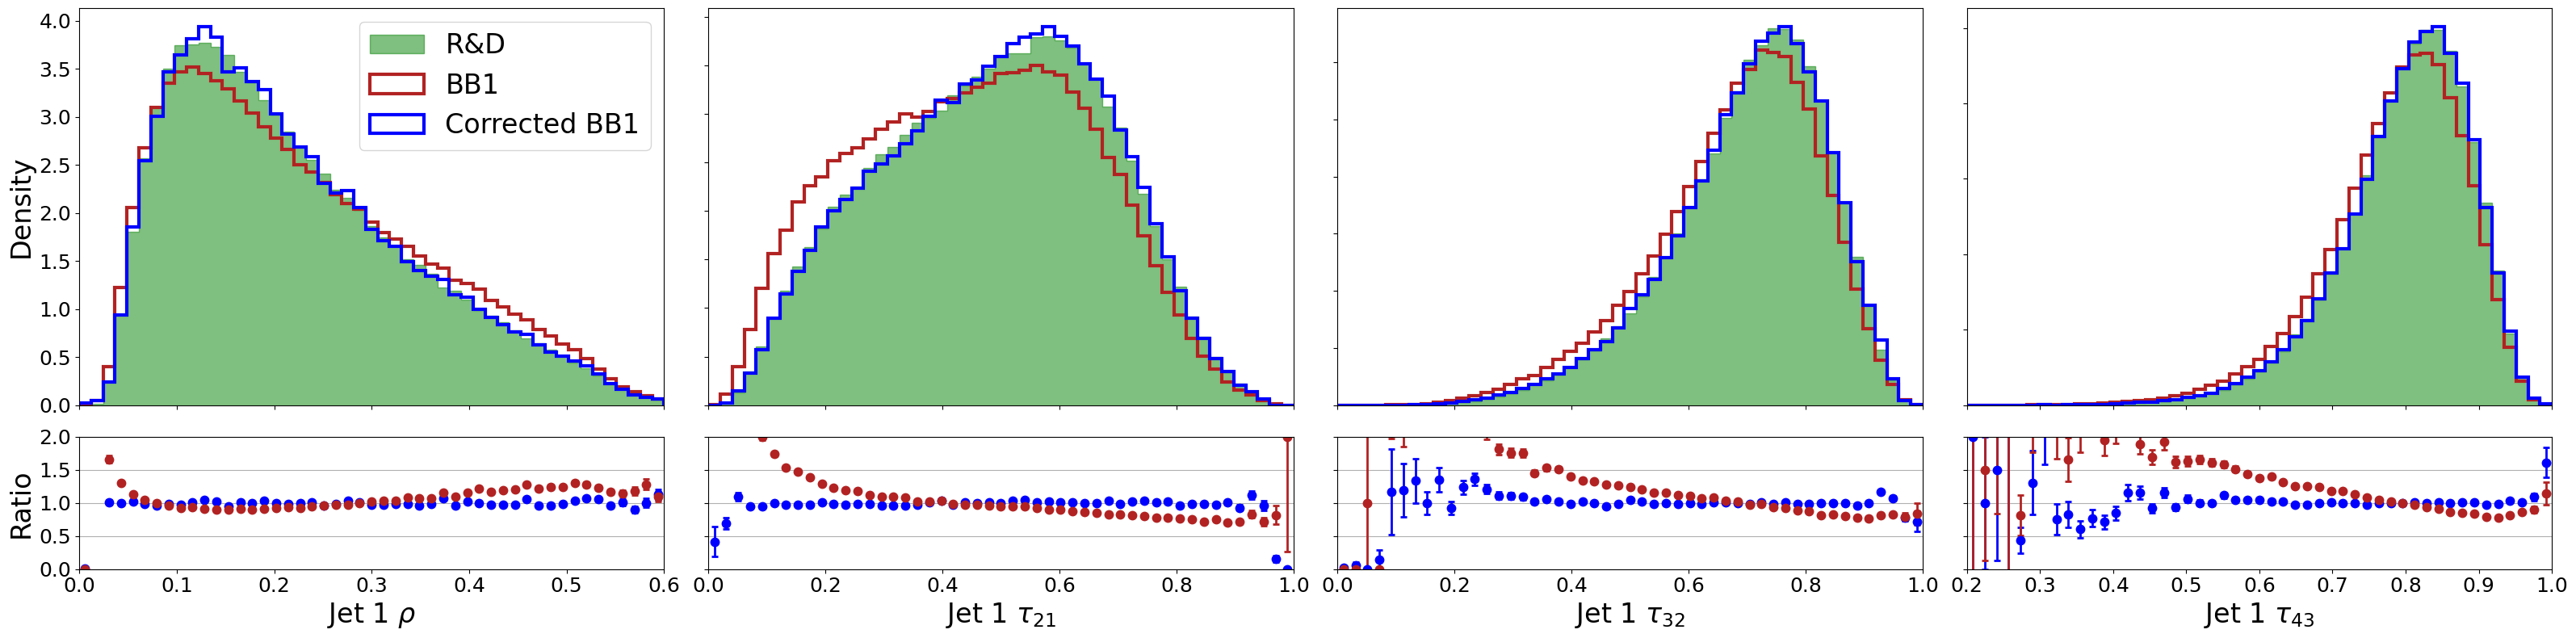

In [22]:
fig,axes = plt.subplots(figsize=(32,8),nrows=2,ncols=4,gridspec_kw={'height_ratios':[3,1]},sharex=False)
names = ['R&D','BB1','Corrected BB1']
colors = ['green','firebrick','blue']
xlims = [[0,0.6],[0,1],[0,1],[0.2,1]]
for i in range(4):
    ax = axes[:,i]
    xlim = xlims[i]
    bins = np.linspace(xlim[0],xlim[1],50)
    qrnn.triplet(rd_all[:,i],corr_b1_all[:,i],b1_all[:,i],ax,names,colors,bins=bins,xlim=xlim)
   
    plt.sca(ax[0])
    xt = plt.gca().get_xticks()
    xt = plt.xticks(xt,labels=len(xt)*[""])
    if i==0:
        plt.legend(loc='upper right',fontsize=24)
        plt.ylabel("Density",fontsize=24)
        yt = plt.yticks(fontsize=18)
    if i>0:
        yt = plt.gca().get_yticks()
        yt = plt.gca().set_yticklabels(len(yt)*[""])
        
    plt.sca(ax[1])
    plt.xlabel(fitvarNames[i],fontsize=24)
    xt = plt.xticks(fontsize=18)
    yt = plt.yticks(fontsize=18)
    if i==0:
        plt.ylabel("Ratio",fontsize=24)
    if i>0:
        yt = plt.gca().get_yticks()
        yt = plt.yticks(yt,labels=len(yt)*[""])
plt.subplots_adjust(wspace=0.08,hspace=0.15)
plt.tight_layout()
plt.savefig(f"NF_models_QR_general/{model_dir}/jet1_corrections_BB1toRD.pdf")

/home/sambt/.local/lib/python3.7/site-packages/ipykernel_launcher.py:20: UserWarning: FixedFormatter should only be used together with FixedLocator
/home/sambt/.local/lib/python3.7/site-packages/ipykernel_launcher.py:20: UserWarning: FixedFormatter should only be used together with FixedLocator
/home/sambt/.local/lib/python3.7/site-packages/ipykernel_launcher.py:20: UserWarning: FixedFormatter should only be used together with FixedLocator


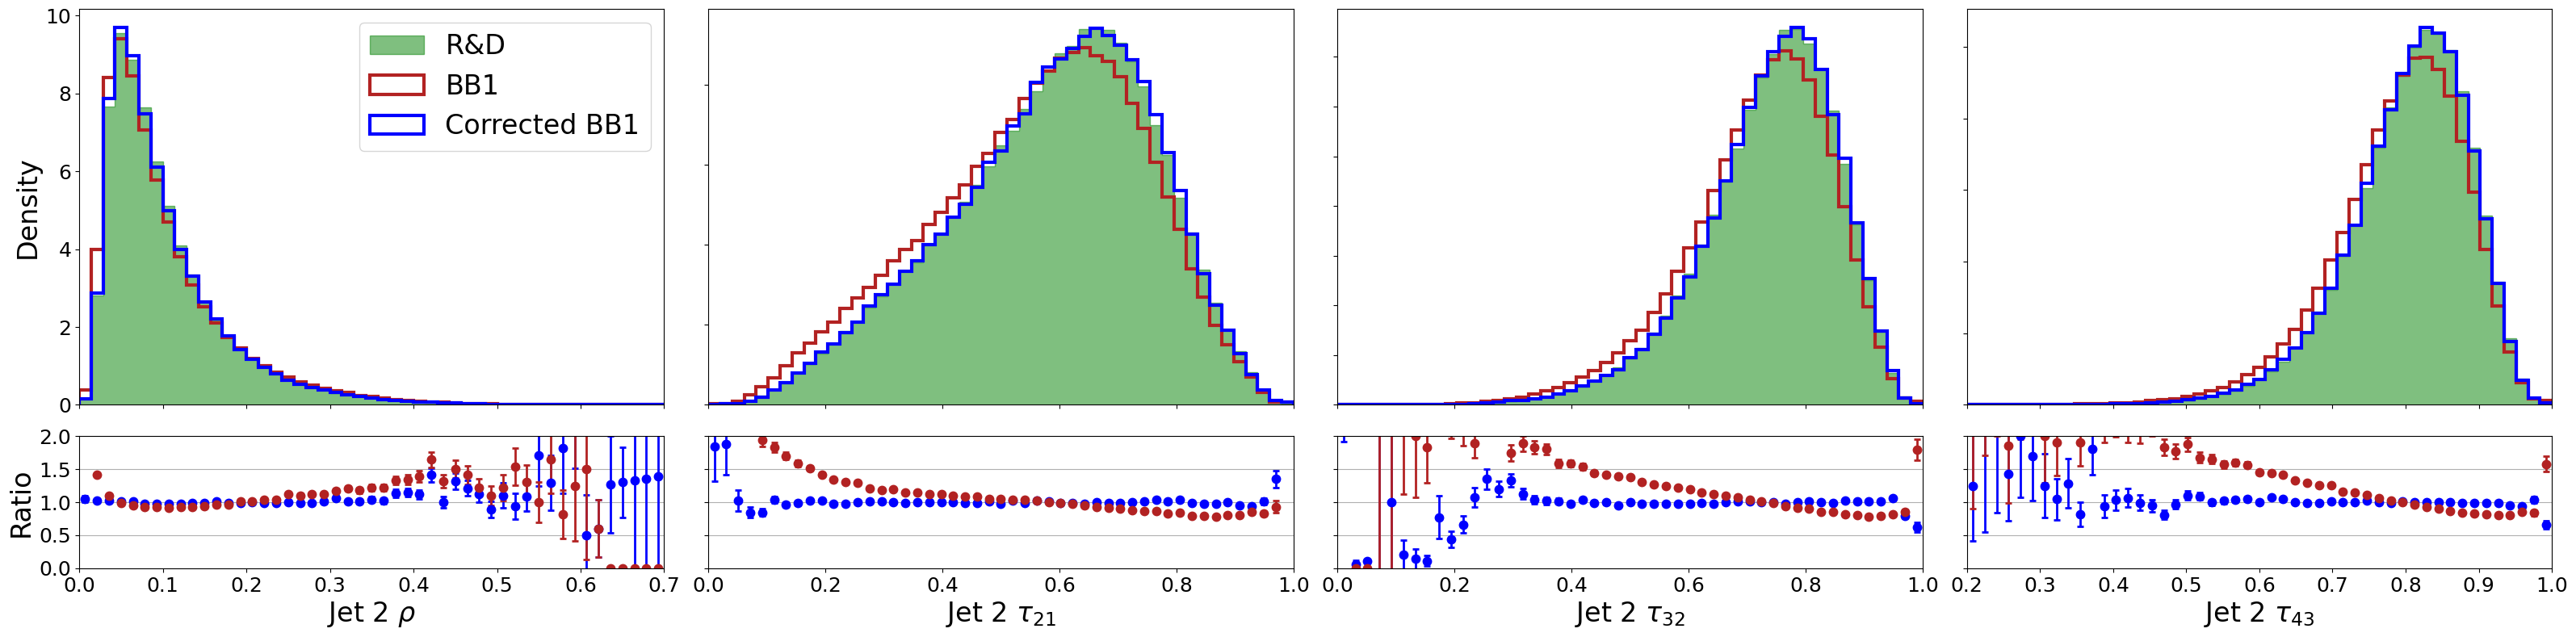

In [23]:
fig,axes = plt.subplots(figsize=(32,8),nrows=2,ncols=4,gridspec_kw={'height_ratios':[3,1]},sharex=False)
names = ['R&D','BB1','Corrected BB1']
colors = ['green','firebrick','blue']
xlims = [[0,0.7],[0,1],[0,1],[0.2,1]]
for i in range(4):
    ax = axes[:,i]
    xlim = xlims[i]
    bins = np.linspace(xlim[0],xlim[1],50)
    qrnn.triplet(rd_all[:,4+i],corr_b1_all[:,4+i],b1_all[:,4+i],ax,names,colors,bins=bins,xlim=xlim)
   
    plt.sca(ax[0])
    xt = plt.gca().get_xticks()
    xt = plt.xticks(xt,labels=len(xt)*[""])
    if i==0:
        plt.legend(loc='upper right',fontsize=24)
        plt.ylabel("Density",fontsize=24)
        yt = plt.yticks(fontsize=18)
    if i>0:
        yt = plt.gca().get_yticks()
        yt = plt.gca().set_yticklabels(len(yt)*[""])
        
    plt.sca(ax[1])
    plt.xlabel(fitvarNames[4+i],fontsize=24)
    xt = plt.xticks(fontsize=18)
    yt = plt.yticks(fontsize=18)
    if i==0:
        plt.ylabel("Ratio",fontsize=24)
    if i>0:
        yt = plt.gca().get_yticks()
        yt = plt.yticks(yt,labels=len(yt)*[""])
plt.subplots_adjust(wspace=0.08,hspace=0.1)
plt.tight_layout()
plt.savefig(f"NF_models_QR_general/{model_dir}/jet2_corrections_BB1toRD.pdf")

# Neural net : distinguish uncorrected from target

In [24]:
train = np.concatenate((b1_train,rd_train),axis=0)
train_lab = np.concatenate((np.zeros((b1_train.shape[0],1)),np.ones((rd_train.shape[0],1))),axis=0)
perm = np.random.permutation(train.shape[0])
train = train[perm]
train_lab = train_lab[perm]

test = np.concatenate((b1_test,rd_test),axis=0)
test_lab = np.concatenate((np.zeros((b1_test.shape[0],1)),np.ones((rd_test.shape[0],1))),axis=0)
perm = np.random.permutation(test.shape[0])
test = test[perm]
test_lab = test_lab[perm]

val = np.concatenate((b1_val,rd_val),axis=0)
val_lab = np.concatenate((np.zeros((b1_val.shape[0],1)),np.ones((rd_val.shape[0],1))),axis=0)
perm = np.random.permutation(val.shape[0])
val = val[perm]
val_lab = val_lab[perm]

mean = train.mean(axis=0)
sd = train.std(axis=0)
train = (train-mean)/sd
test = (test-mean)/sd
val = (val-mean)/sd

n_in = train.shape[1]
n_hidden = 64
num_hidden = 6
n_out = 1
act = nn.ReLU()
out_act = nn.Sigmoid()

n_iter = 10
aucs = []
plt.figure(figsize=(8,6))

tprs_bb1vsrd = []
fprs_bb1vsrd = []

fin = "/nobackup/users/sambt/QR_samples/LHCO/morphed_outputs/plotData.h5"
with h5py.File(fin,"r") as f:
    print(list(f.keys()))
    print(list(f['RDtoContamBB1'].keys()))

if not os.path.isdir(f"NF_models_QR_general/{model_dir}/NN_bb1_vs_rdPythia/"):
    os.mkdir(f"NF_models_QR_general/{model_dir}/NN_bb1_vs_rdPythia/")
for i in range(n_iter):
    #torch.manual_seed(np.random.randint(10000000,size=1)[0])
    #net1 = qrnn.NeuralNet(n_in, n_hidden, n_out, num_hidden, act=act, out_act=out_act,dropout=0.1)
    #net1,loss,val_loss = qrnn.train_nn(net1,train,train_lab,val,val_lab,n_epoch=3,lr=5e-4,bs=1024,lossfunc="BCE",plot=False,losses=True)
    #torch.save(net1,f"NF_models_QR_general/{model_dir}/NN_bb1_vs_rdPythia/training_{i}.pt")
    #plt.plot(np.arange(len(loss)),loss,color=f"C{i}")
    #plt.plot(np.linspace(0,len(loss),len(val_loss)),val_loss,color=f"C{i}",linestyle='--')
    
    net1 = torch.load(f"NF_models_QR_general/{model_dir}/NN_bb1_vs_rdPythia/training_{i}.pt")
    
    net1 = net1.to(device)
    with torch.no_grad():
        preds = net1(torch.tensor(test,device=device,dtype=torch.float32)).cpu().numpy()
    auc = roc_auc_score(test_lab,preds)
    aucs.append(auc)
    fpr,tpr,thresh = roc_curve(test_lab,preds)
    fprs_bb1vsrd.append(fpr)
    tprs_bb1vsrd.append(tpr)
    
    del preds, net1
    torch.cuda.empty_cache()

<Figure size 800x600 with 0 Axes>

In [12]:
print(f"R&D vs BB1 AUC: {np.mean(aucs)} +/- {np.std(aucs)}")

R&D vs BB1 AUC: 0.6250592768703561 +/- 0.0002772890070533162


# Neural net : distinguish corrected bb1 from r&d

In [26]:
train = np.concatenate((corr_b1_train,rd_train),axis=0)
train_lab = np.concatenate((np.zeros((b1_train.shape[0],1)),np.ones((rd_train.shape[0],1))),axis=0)
perm = np.random.permutation(train.shape[0])
train = train[perm]
train_lab = train_lab[perm]

test = np.concatenate((corr_b1_test,rd_test),axis=0)
test_lab = np.concatenate((np.zeros((b1_test.shape[0],1)),np.ones((rd_test.shape[0],1))),axis=0)
perm = np.random.permutation(test.shape[0])
test = test[perm]
test_lab = test_lab[perm]

val = np.concatenate((corr_b1_val,rd_val),axis=0)
val_lab = np.concatenate((np.zeros((b1_val.shape[0],1)),np.ones((rd_val.shape[0],1))),axis=0)
perm = np.random.permutation(val.shape[0])
val = val[perm]
val_lab = val_lab[perm]

mean = train.mean(axis=0)
sd = train.std(axis=0)
train = (train-mean)/sd
test = (test-mean)/sd
val = (val-mean)/sd

n_in = train.shape[1]
n_hidden = 64
num_hidden = 6
n_out = 1
act = nn.ReLU()
out_act = nn.Sigmoid()

n_iter = 10
aucs = []
plt.figure(figsize=(8,6))
tprs_corrb1vsrd = []
fprs_corrb1vsrd = []
if not os.path.isdir(f"NF_models_QR_general/{model_dir}/NN_corr_bb1_vs_rdPythia/"):
    os.mkdir(f"NF_models_QR_general/{model_dir}/NN_corr_bb1_vs_rdPythia/")
for i in range(n_iter):
    #torch.manual_seed(np.random.randint(10000000,size=1)[0])
    #net1 = qrnn.NeuralNet(n_in, n_hidden, n_out, num_hidden, act=act, out_act=out_act,dropout=0.1)
    #net1,loss,val_loss = qrnn.train_nn(net1,train,train_lab,val,val_lab,n_epoch=3,lr=5e-4,bs=1024,lossfunc="BCE",plot=False,losses=True)
    #torch.save(net1,f"NF_models_QR_general/{model_dir}/NN_corr_bb1_vs_rdPythia/training_{i}.pt")
    #plt.plot(np.arange(len(loss)),loss,color=f"C{i}")
    #plt.plot(np.linspace(0,len(loss),len(val_loss)),val_loss,color=f"C{i}",linestyle='--')
    
    net1 = torch.load(f"NF_models_QR_general/{model_dir}/NN_corr_bb1_vs_rdPythia/training_{i}.pt")
    
    net1 = net1.to(device)
    with torch.no_grad():
        preds = net1(torch.tensor(test,device=device,dtype=torch.float32)).cpu().numpy()
    auc = roc_auc_score(test_lab,preds)
    aucs.append(auc)
    fpr,tpr,thresh = roc_curve(test_lab,preds)
    fprs_corrb1vsrd.append(fpr)
    tprs_corrb1vsrd.append(tpr)
    
    del preds, net1
    torch.cuda.empty_cache()

<Figure size 800x600 with 0 Axes>

In [27]:
print(f"R&D vs Corrected BB1 AUC: {np.mean(aucs)} +/- {np.std(aucs)}")

R&D vs Corrected BB1 AUC: 0.5117343315526518 +/- 0.0005932283250892913


# Neural net : distinguish bb1 from corrected r&d

In [32]:
train = np.concatenate((b1_train,corr_rd_train),axis=0)
train_lab = np.concatenate((np.zeros((b1_train.shape[0],1)),np.ones((corr_rd_train.shape[0],1))),axis=0)
perm = np.random.permutation(train.shape[0])
train = train[perm]
train_lab = train_lab[perm]

test = np.concatenate((b1_test,corr_rd_test),axis=0)
test_lab = np.concatenate((np.zeros((b1_test.shape[0],1)),np.ones((corr_rd_test.shape[0],1))),axis=0)
perm = np.random.permutation(test.shape[0])
test = test[perm]
test_lab = test_lab[perm]

val = np.concatenate((b1_val,corr_rd_val),axis=0)
val_lab = np.concatenate((np.zeros((b1_val.shape[0],1)),np.ones((corr_rd_val.shape[0],1))),axis=0)
perm = np.random.permutation(val.shape[0])
val = val[perm]
val_lab = val_lab[perm]

mean = train.mean(axis=0)
sd = train.std(axis=0)
train = (train-mean)/sd
test = (test-mean)/sd
val = (val-mean)/sd

n_in = train.shape[1]
n_hidden = 64
num_hidden = 6
n_out = 1
act = nn.ReLU()
out_act = nn.Sigmoid()

n_iter = 10
aucs = []
plt.figure(figsize=(8,6))
tprs_b1vscorrrd = []
fprs_b1vscorrrd = []
if not os.path.isdir(f"NF_models_QR_general/{model_dir}/NN_bb1_vs_corr_rdPythia/"):
    os.mkdir(f"NF_models_QR_general/{model_dir}/NN_bb1_vs_corr_rdPythia/")
for i in range(n_iter):
    #torch.manual_seed(np.random.randint(10000000,size=1)[0])
    #net1 = qrnn.NeuralNet(n_in, n_hidden, n_out, num_hidden, act=act, out_act=out_act,dropout=0.1)
    #net1,loss,val_loss = qrnn.train_nn(net1,train,train_lab,val,val_lab,n_epoch=5,lr=5e-4,bs=1024,lossfunc="BCE",plot=False,losses=True)
    #torch.save(net1,f"NF_models_QR_general/{model_dir}/NN_bb1_vs_corr_rdPythia/training_{i}.pt")
    #plt.plot(np.arange(len(loss)),loss,color=f"C{i}")
    #plt.plot(np.linspace(0,len(loss),len(val_loss)),val_loss,color=f"C{i}",linestyle='--')
    
    net1 = torch.load(f"NF_models_QR_general/{model_dir}/NN_bb1_vs_corr_rdPythia/training_{i}.pt")
    
    net1 = net1.to(device)
    with torch.no_grad():
        preds = net1(torch.tensor(test,device=device,dtype=torch.float32)).cpu().numpy()
    auc = roc_auc_score(test_lab,preds)
    aucs.append(auc)
    fpr,tpr,thresh = roc_curve(test_lab,preds)
    fprs_b1vscorrrd.append(fpr)
    tprs_b1vscorrrd.append(tpr)
    
    del preds, net1
    torch.cuda.empty_cache()

<Figure size 800x600 with 0 Axes>

In [33]:
print(f"Corrected R&D vs BB1 AUC: {np.mean(aucs)} +/- {np.std(aucs)}")

Corrected R&D vs BB1 AUC: 0.513409920465027 +/- 0.0005412877175325165


# ROC Curves for talk

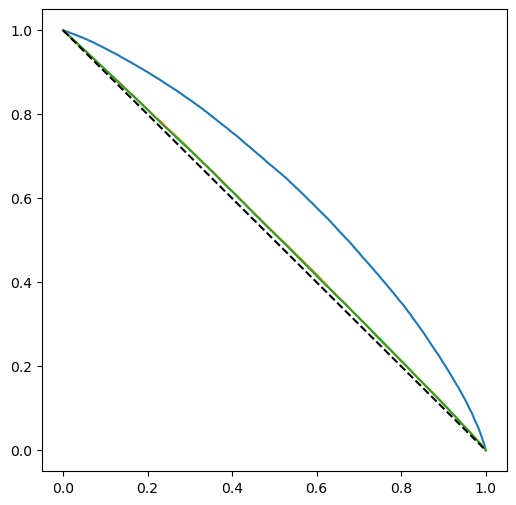

In [36]:
plt.figure(figsize=(6,6))
plt.plot(tprs_bb1vsrd[0],1-fprs_bb1vsrd[0],label="BB1 vs. R&D")
plt.plot(tprs_b1vscorrrd[0],1-fprs_b1vscorrrd[0],label="BB1 vs. Morphed R&D")
plt.plot(tprs_corrb1vsrd[0],1-fprs_corrb1vsrd[0],label="Morphed BB1 vs. R&D")
plt.plot(tprs_bb1vsrd[0],1-tprs_bb1vsrd[0],label="Random",color='black',linestyle='--')

# Neural net : distinguish bb1 from signal

In [13]:
train = np.concatenate((b1_train,rd_sig_train),axis=0)
train_lab = np.concatenate((np.zeros((b1_train.shape[0],1)),np.ones((rd_sig_train.shape[0],1))),axis=0)
perm = np.random.permutation(train.shape[0])
train = train[perm]
train_lab = train_lab[perm]

test = np.concatenate((b1_test,rd_sig_test),axis=0)
test_lab = np.concatenate((np.zeros((b1_test.shape[0],1)),np.ones((rd_sig_test.shape[0],1))),axis=0)
perm = np.random.permutation(test.shape[0])
test = test[perm]
test_lab = test_lab[perm]

val = np.concatenate((b1_val,rd_sig_val),axis=0)
val_lab = np.concatenate((np.zeros((b1_val.shape[0],1)),np.ones((rd_sig_val.shape[0],1))),axis=0)
perm = np.random.permutation(val.shape[0])
val = val[perm]
val_lab = val_lab[perm]

test_rd = np.concatenate((rd_test,rd_sig_test),axis=0)
test_rd_lab = np.concatenate((np.zeros((rd_test.shape[0],1)),np.ones((rd_sig_test.shape[0],1))),axis=0)
perm = np.random.permutation(test_rd.shape[0])
test_rd = test_rd[perm]
test_rd_lab = test_rd_lab[perm]

test_corr_b1 = np.concatenate((corr_b1_test,rd_sig_test),axis=0)
test_corr_b1_lab = np.concatenate((np.zeros((corr_b1_test.shape[0],1)),np.ones((rd_sig_test.shape[0],1))),axis=0)
perm = np.random.permutation(test_corr_b1.shape[0])
test_corr_b1 = test_corr_b1[perm]
test_corr_b1_lab = test_corr_b1_lab[perm]

mean = train.mean(axis=0)
sd = train.std(axis=0)
train = (train-mean)/sd
test = (test-mean)/sd
val = (val-mean)/sd
test_rd = (test_rd-mean)/sd
test_corr_b1 = (test_corr_b1-mean)/sd

n_in = train.shape[1]
n_hidden = 16
num_hidden = 2
n_out = 1
act = nn.ReLU()
out_act = nn.Sigmoid()

n_iter = 10

aucs = []
aucs_rd = []
aucs_corr_b1 = []
tprs = []
tprs_rd = []
tprs_corr_b1 = []
fprs = []
fprs_rd = []
fprs_corr_b1 = []

plt.figure(figsize=(8,6))
if not os.path.isdir(f"NF_models_QR_general/{model_dir}/NN_bb1_vs_rdSignal/"):
    os.mkdir(f"NF_models_QR_general/{model_dir}/NN_bb1_vs_rdSignal/")
for i in range(n_iter):
    #torch.manual_seed(np.random.randint(10000000,size=1)[0])
    #net1 = qrnn.NeuralNet(n_in, n_hidden, n_out, num_hidden, act=act, out_act=out_act,dropout=0.1)
    #net1,loss,val_loss = qrnn.train_nn(net1,train,train_lab,val,val_lab,n_epoch=5,lr=5e-4,bs=1024,lossfunc="BCE",plot=False,losses=True)
    #plt.plot(np.arange(len(loss)),loss,color=f"C{i}")
    #plt.plot(np.linspace(0,len(loss),len(val_loss)),val_loss,color=f"C{i}",linestyle='--')
    #torch.save(net1,f"NF_models_QR_general/{model_dir}/NN_bb1_vs_rdSignal/training_{i}.pt")
    
    net1 = torch.load(f"NF_models_QR_general/{model_dir}/NN_bb1_vs_rdSignal/training_{i}.pt")
    
    
    net1 = net1.to(device)
    with torch.no_grad():
        preds = net1(torch.tensor(test,device=device,dtype=torch.float32)).cpu().numpy()
        preds_rd = net1(torch.tensor(test_rd,device=device,dtype=torch.float32)).cpu().numpy()
        preds_corr_b1 = net1(torch.tensor(test_corr_b1,device=device,dtype=torch.float32)).cpu().numpy()
    
    aucs.append(roc_auc_score(test_lab,preds))
    aucs_rd.append(roc_auc_score(test_rd_lab,preds_rd))
    aucs_corr_b1.append(roc_auc_score(test_corr_b1_lab,preds_corr_b1))
    
    fpr,tpr,thresh = roc_curve(test_lab,preds)
    tprs.append(tpr)
    fprs.append(fpr)
    fpr,tpr,thresh = roc_curve(test_rd_lab,preds_rd)
    tprs_rd.append(tpr)
    fprs_rd.append(fpr)
    fpr,tpr,thresh = roc_curve(test_corr_b1_lab,preds_corr_b1)
    tprs_corr_b1.append(tpr)
    fprs_corr_b1.append(fpr)
    
    del preds, preds_rd, preds_corr_b1, net1
    torch.cuda.empty_cache()

<Figure size 800x600 with 0 Axes>

In [14]:
print(f"BB1 (trained on) vs signal AUC: {np.mean(aucs)} +/- {np.std(aucs)}")
print(f"R&D (not trained on) vs signal AUC: {np.mean(aucs_rd)} +/- {np.std(aucs_rd)}")
print(f"Corrected BB1 (not trained on) vs signal AUC: {np.mean(aucs_corr_b1)} +/- {np.std(aucs_corr_b1)}")

BB1 (trained on) vs signal AUC: 0.9249164321355368 +/- 0.0018224775567984618
R&D (not trained on) vs signal AUC: 0.948443678656 +/- 0.0011992692572825449
Corrected BB1 (not trained on) vs signal AUC: 0.9487898292659492 +/- 0.0012037448853656149


In [15]:
sics = [np.divide(tprs[i],np.sqrt(fprs[i]),where=fprs[i]>0) for i in range(len(tprs))]
sics_rd = [np.divide(tprs_rd[i],np.sqrt(fprs_rd[i]),where=fprs_rd[i]>0) for i in range(len(tprs))]
sics_corr_b1 = [np.divide(tprs_corr_b1[i],np.sqrt(fprs_corr_b1[i]),where=fprs_corr_b1[i]>0) for i in range(len(tprs))]

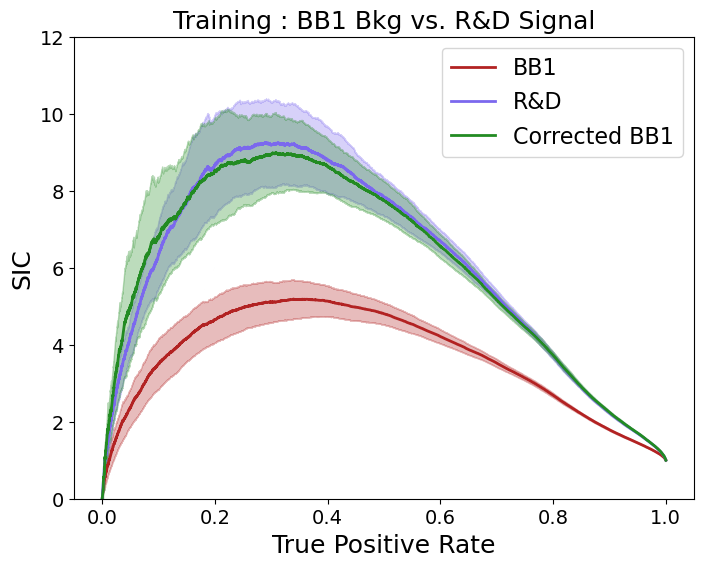

In [16]:
x = np.linspace(0,1,30000)
plt.figure(figsize=(8,6))

lw=2

smoothed = []
for i in range(len(sics)):
    smoothed.append(np.interp(x,tprs[i],sics[i]).reshape(-1,1))
smoothed = np.concatenate(smoothed,axis=1)
mean_sic = np.mean(smoothed,axis=1)
sd_sic = np.std(smoothed,axis=1)
plt.fill_between(x,mean_sic-sd_sic,mean_sic+sd_sic,color='firebrick',alpha=0.3,zorder=1)
plt.plot(x,mean_sic,color='firebrick',label="BB1",zorder=2,linewidth=lw)

smoothed = []
for i in range(len(sics)):
    smoothed.append(np.interp(x,tprs_rd[i],sics_rd[i]).reshape(-1,1))
smoothed = np.concatenate(smoothed,axis=1)
mean_sic = np.mean(smoothed,axis=1)
sd_sic = np.std(smoothed,axis=1)
plt.fill_between(x,mean_sic-sd_sic,mean_sic+sd_sic,color='mediumslateblue',alpha=0.3,zorder=1)
plt.plot(x,mean_sic,color='mediumslateblue',label="R&D",zorder=2,linewidth=lw)

smoothed = []
for i in range(len(sics)):
    smoothed.append(np.interp(x,tprs_corr_b1[i],sics_corr_b1[i]).reshape(-1,1))
smoothed = np.concatenate(smoothed,axis=1)
mean_sic = np.mean(smoothed,axis=1)
sd_sic = np.std(smoothed,axis=1)
plt.fill_between(x,mean_sic-sd_sic,mean_sic+sd_sic,color='forestgreen',alpha=0.3,zorder=1)
plt.plot(x,mean_sic,color='forestgreen',label="Corrected BB1",zorder=2,linewidth=lw)

plt.legend(loc='upper right',fontsize=16)
plt.xlabel('True Positive Rate',fontsize=18)
plt.ylabel('SIC',fontsize=18)
plt.ylim([0,12])
xt = plt.xticks(fontsize=14)
yt = plt.yticks(fontsize=14)
plt.title("Training : BB1 Bkg vs. R&D Signal",fontsize=18)

plt.savefig(f"NF_models_QR_general/{model_dir}/NN_bb1_vs_rdSignal/sic_comparison_trainBB1vsRDSignal.pdf")

# Neural net : distinguish RD bkg from signal

In [24]:
train = np.concatenate((rd_train,rd_sig_train),axis=0)
train_lab = np.concatenate((np.zeros((rd_train.shape[0],1)),np.ones((rd_sig_train.shape[0],1))),axis=0)
perm = np.random.permutation(train.shape[0])
train = train[perm]
train_lab = train_lab[perm]

test = np.concatenate((rd_test,rd_sig_test),axis=0)
test_lab = np.concatenate((np.zeros((rd_test.shape[0],1)),np.ones((rd_sig_test.shape[0],1))),axis=0)
perm = np.random.permutation(test.shape[0])
test = test[perm]
test_lab = test_lab[perm]

val = np.concatenate((rd_val,rd_sig_val),axis=0)
val_lab = np.concatenate((np.zeros((rd_val.shape[0],1)),np.ones((rd_sig_val.shape[0],1))),axis=0)
perm = np.random.permutation(val.shape[0])
val = val[perm]
val_lab = val_lab[perm]

test_b1 = np.concatenate((b1_test,rd_sig_test),axis=0)
test_b1_lab = np.concatenate((np.zeros((b1_test.shape[0],1)),np.ones((rd_sig_test.shape[0],1))),axis=0)
perm = np.random.permutation(test_b1.shape[0])
test_b1 = test_b1[perm]
test_b1_lab = test_b1_lab[perm]

test_corr_rd = np.concatenate((corr_rd_test,rd_sig_test),axis=0)
test_corr_rd_lab = np.concatenate((np.zeros((corr_rd_test.shape[0],1)),np.ones((rd_sig_test.shape[0],1))),axis=0)
perm = np.random.permutation(test_corr_rd.shape[0])
test_corr_rd = test_corr_rd[perm]
test_corr_rd_lab = test_corr_rd_lab[perm]

mean = train.mean(axis=0)
sd = train.std(axis=0)
train = (train-mean)/sd
test = (test-mean)/sd
val = (val-mean)/sd
test_b1 = (test_b1-mean)/sd
test_corr_rd = (test_corr_rd-mean)/sd

n_in = train.shape[1]
n_hidden = 16
num_hidden = 2
n_out = 1
act = nn.ReLU()
out_act = nn.Sigmoid()

n_iter = 10

aucs = []
aucs_b1 = []
aucs_corr_rd = []
tprs = []
tprs_b1 = []
tprs_corr_rd = []
fprs = []
fprs_b1 = []
fprs_corr_rd = []

preds_bkg = []
preds_corr_bkg = []
preds_b1_bkg = []

plt.figure(figsize=(8,6))
if not os.path.isdir(f"NF_models_QR_general/{model_dir}/NN_rd_vs_rdSignal/"):
    os.mkdir(f"NF_models_QR_general/{model_dir}/NN_rd_vs_rdSignal/")
for i in range(n_iter):
    #torch.manual_seed(np.random.randint(10000000,size=1)[0])
    #net1 = qrnn.NeuralNet(n_in, n_hidden, n_out, num_hidden, act=act, out_act=out_act,dropout=0.1)
    #net1,loss,val_loss = qrnn.train_nn(net1,train,train_lab,val,val_lab,n_epoch=5,lr=5e-4,bs=1024,lossfunc="BCE",plot=False,losses=True)
    #plt.plot(np.arange(len(loss)),loss,color=f"C{i}")
    #plt.plot(np.linspace(0,len(loss),len(val_loss)),val_loss,color=f"C{i}",linestyle='--')
    #torch.save(net1,f"NF_models_QR_general/{model_dir}/NN_rd_vs_rdSignal/training_{i}.pt")
    
    net1 = torch.load(f"NF_models_QR_general/{model_dir}/NN_rd_vs_rdSignal/training_{i}.pt")
    
    
    net1 = net1.to(device)
    with torch.no_grad():
        preds = net1(torch.tensor(test,device=device,dtype=torch.float32)).cpu().numpy()
        preds_b1 = net1(torch.tensor(test_b1,device=device,dtype=torch.float32)).cpu().numpy()
        preds_corr_rd = net1(torch.tensor(test_corr_rd,device=device,dtype=torch.float32)).cpu().numpy()
        
    preds_bkg.append(preds[test_lab==0])
    preds_corr_bkg.append(preds_corr_rd[test_corr_rd_lab==0])
    preds_b1_bkg.append(preds_b1[test_b1_lab==0])
    
    aucs.append(roc_auc_score(test_lab,preds))
    aucs_b1.append(roc_auc_score(test_b1_lab,preds_b1))
    aucs_corr_rd.append(roc_auc_score(test_corr_rd_lab,preds_corr_rd))
    
    fpr,tpr,thresh = roc_curve(test_lab,preds)
    tprs.append(tpr)
    fprs.append(fpr)
    fpr,tpr,thresh = roc_curve(test_b1_lab,preds_b1)
    tprs_b1.append(tpr)
    fprs_b1.append(fpr)
    fpr,tpr,thresh = roc_curve(test_corr_rd_lab,preds_corr_rd)
    tprs_corr_rd.append(tpr)
    fprs_corr_rd.append(fpr)
    
    del preds, preds_b1, preds_corr_rd, net1
    torch.cuda.empty_cache()

<Figure size 800x600 with 0 Axes>

In [25]:
print(f"RD (trained on) vs signal AUC: {np.mean(aucs)} +/- {np.std(aucs)}")
print(f"BB1 (not trained on) vs signal AUC: {np.mean(aucs_b1)} +/- {np.std(aucs_b1)}")
print(f"Corrected RD (not trained on) vs signal AUC: {np.mean(aucs_corr_rd)} +/- {np.std(aucs_corr_rd)}")

RD (trained on) vs signal AUC: 0.950756008784 +/- 0.0007382205017596221
BB1 (not trained on) vs signal AUC: 0.9223870264540096 +/- 0.0016215241217240836
Corrected RD (not trained on) vs signal AUC: 0.921452158304 +/- 0.0016130418028004144


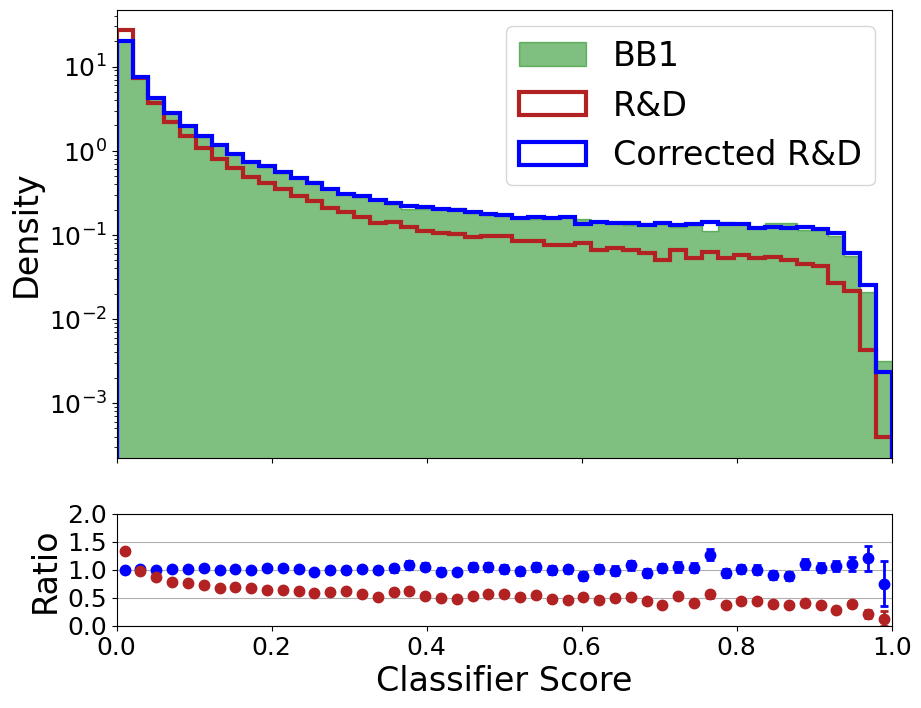

In [36]:
i=4

fig,axes = plt.subplots(figsize=(10,8),nrows=2,ncols=1,gridspec_kw={'height_ratios':[4,1]},sharex=False)
names = ['BB1','R&D','Corrected R&D']
colors = ['green','firebrick','blue']
xlims = [[0,0.6],[0,1],[0,1],[0.2,1]]
xlim = [0,1]
bins = np.linspace(xlim[0],xlim[1],50)
qrnn.triplet(preds_b1_bkg[i],preds_corr_bkg[i],preds_bkg[i],axes,names,colors,bins=bins,xlim=xlim)

plt.sca(axes[0])
plt.yscale('log')
xt = plt.gca().get_xticks()
xt = plt.xticks(xt,labels=len(xt)*[""])
plt.legend(loc='upper right',fontsize=24)
plt.ylabel("Density",fontsize=24)
yt = plt.yticks(fontsize=18)

plt.sca(axes[1])
plt.xlabel("Classifier Score",fontsize=24)
xt = plt.xticks(fontsize=18)
yt = plt.yticks(fontsize=18)
plt.ylabel("Ratio",fontsize=24)
plt.savefig(f"NF_models_QR_general/{model_dir}/NNscores_RDtoBB1.pdf")

In [19]:
sics = [np.divide(tprs[i],np.sqrt(fprs[i]),where=fprs[i]>0) for i in range(len(tprs))]
sics_b1 = [np.divide(tprs_b1[i],np.sqrt(fprs_b1[i]),where=fprs_b1[i]>0) for i in range(len(tprs))]
sics_corr_rd = [np.divide(tprs_corr_rd[i],np.sqrt(fprs_corr_rd[i]),where=fprs_corr_rd[i]>0) for i in range(len(tprs))]

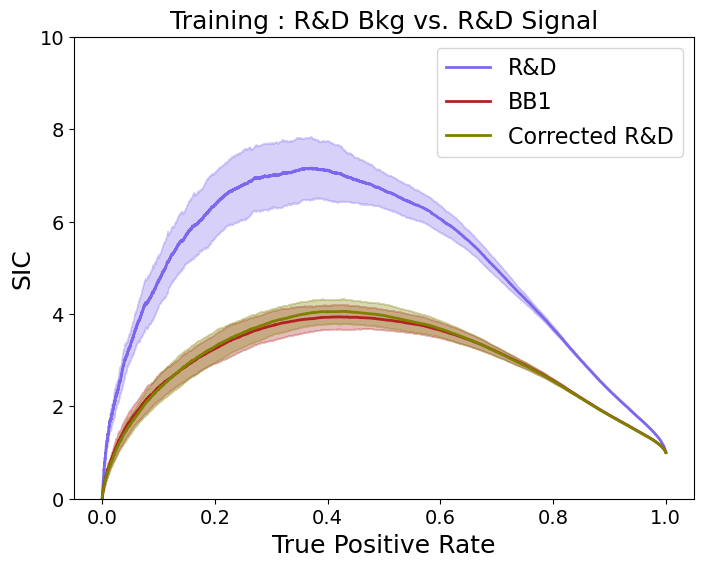

In [21]:
x = np.linspace(0,1,30000)
plt.figure(figsize=(8,6))

lw=2

smoothed = []
for i in range(len(sics)):
    smoothed.append(np.interp(x,tprs[i],sics[i]).reshape(-1,1))
smoothed = np.concatenate(smoothed,axis=1)
mean_sic = np.mean(smoothed,axis=1)
sd_sic = np.std(smoothed,axis=1)
plt.fill_between(x,mean_sic-sd_sic,mean_sic+sd_sic,color='mediumslateblue',alpha=0.3,zorder=1)
plt.plot(x,mean_sic,color='mediumslateblue',label="R&D",zorder=2,linewidth=lw)

smoothed = []
for i in range(len(sics)):
    smoothed.append(np.interp(x,tprs_b1[i],sics_b1[i]).reshape(-1,1))
smoothed = np.concatenate(smoothed,axis=1)
mean_sic = np.mean(smoothed,axis=1)
sd_sic = np.std(smoothed,axis=1)
plt.fill_between(x,mean_sic-sd_sic,mean_sic+sd_sic,color='firebrick',alpha=0.3,zorder=1)
plt.plot(x,mean_sic,color='firebrick',label="BB1",zorder=2,linewidth=lw)

smoothed = []
for i in range(len(sics)):
    smoothed.append(np.interp(x,tprs_corr_rd[i],sics_corr_rd[i]).reshape(-1,1))
smoothed = np.concatenate(smoothed,axis=1)
mean_sic = np.mean(smoothed,axis=1)
sd_sic = np.std(smoothed,axis=1)
plt.fill_between(x,mean_sic-sd_sic,mean_sic+sd_sic,color='olive',alpha=0.3,zorder=1)
plt.plot(x,mean_sic,color='olive',label="Corrected R&D",zorder=2,linewidth=lw)

plt.ylim([0,10])
plt.legend(loc='upper right',fontsize=16)
plt.xlabel('True Positive Rate',fontsize=18)
plt.ylabel('SIC',fontsize=18)
xt = plt.xticks(fontsize=14)
yt = plt.yticks(fontsize=14)
plt.title("Training : R&D Bkg vs. R&D Signal",fontsize=18)

plt.savefig(f"NF_models_QR_general/{model_dir}/NN_rd_vs_rdSignal/sic_comparison_trainRDvsRDSignal.pdf")

# Neural net : distinguish corrected pythia RD from signal

In [5]:
train = np.concatenate((corr_rd_train,rd_sig_train),axis=0)
train_lab = np.concatenate((np.zeros((corr_rd_train.shape[0],1)),np.ones((rd_sig_train.shape[0],1))),axis=0)
perm = np.random.permutation(train.shape[0])
train = train[perm]
train_lab = train_lab[perm]

test = np.concatenate((corr_rd_test,rd_sig_test),axis=0)
test_lab = np.concatenate((np.zeros((corr_rd_test.shape[0],1)),np.ones((rd_sig_test.shape[0],1))),axis=0)
perm = np.random.permutation(test.shape[0])
test = test[perm]
test_lab = test_lab[perm]

val = np.concatenate((corr_rd_val,rd_sig_val),axis=0)
val_lab = np.concatenate((np.zeros((corr_rd_val.shape[0],1)),np.ones((rd_sig_val.shape[0],1))),axis=0)
perm = np.random.permutation(val.shape[0])
val = val[perm]
val_lab = val_lab[perm]

test_b1 = np.concatenate((b1_test,rd_sig_test),axis=0)
test_b1_lab = np.concatenate((np.zeros((b1_test.shape[0],1)),np.ones((rd_sig_test.shape[0],1))),axis=0)
perm = np.random.permutation(test_b1.shape[0])
test_b1 = test_b1[perm]
test_b1_lab = test_b1_lab[perm]

test_rd = np.concatenate((rd_test,rd_sig_test),axis=0)
test_rd_lab = np.concatenate((np.zeros((rd_test.shape[0],1)),np.ones((rd_sig_test.shape[0],1))),axis=0)
perm = np.random.permutation(test_rd.shape[0])
test_rd = test_rd[perm]
test_rd_lab = test_rd_lab[perm]

test_corr_b1 = np.concatenate((corr_b1_test,rd_sig_test),axis=0)
test_corr_b1_lab = np.concatenate((np.zeros((corr_b1_test.shape[0],1)),np.ones((rd_sig_test.shape[0],1))),axis=0)
perm = np.random.permutation(test_corr_b1.shape[0])
test_corr_b1 = test_corr_b1[perm]
test_corr_b1_lab = test_corr_b1_lab[perm]

mean = train.mean(axis=0)
sd = train.std(axis=0)
train = (train-mean)/sd
test = (test-mean)/sd
val = (val-mean)/sd
test_b1 = (test_b1-mean)/sd
test_rd = (test_rd-mean)/sd
test_corr_b1 = (test_corr_b1-mean)/sd

n_in = train.shape[1]
n_hidden = 16
num_hidden = 2
n_out = 1
act = nn.ReLU()
out_act = nn.Sigmoid()

n_iter = 10

aucs = []
aucs_b1 = []
aucs_rd = []
aucs_corr_b1 = []
tprs = []
tprs_b1 = []
tprs_rd = []
tprs_corr_b1 = []
fprs = []
fprs_rd = []
fprs_b1 = []
fprs_corr_b1 = []

plt.figure(figsize=(8,6))
if not os.path.isdir(f"NF_models_QR_general/{model_dir}/NN_corr_rd_vs_rdSignal/"):
    os.mkdir(f"NF_models_QR_general/{model_dir}/NN_corr_rd_vs_rdSignal/")
for i in range(n_iter):
    #torch.manual_seed(np.random.randint(10000000,size=1)[0])
    #net1 = qrnn.NeuralNet(n_in, n_hidden, n_out, num_hidden, act=act, out_act=out_act,dropout=0.1)
    #net1,loss,val_loss = qrnn.train_nn(net1,train,train_lab,val,val_lab,n_epoch=5,lr=5e-4,bs=1024,lossfunc="BCE",plot=False,losses=True)
    #plt.plot(np.arange(len(loss)),loss,color=f"C{i}")
    #plt.plot(np.linspace(0,len(loss),len(val_loss)),val_loss,color=f"C{i}",linestyle='--')
    #torch.save(net1,f"NF_models_QR_general/{model_dir}/NN_corr_rd_vs_rdSignal/training_{i}.pt")
    
    net1 = torch.load(f"NF_models_QR_general/{model_dir}/NN_corr_rd_vs_rdSignal/training_{i}.pt")
    
    
    net1 = net1.to(device)
    with torch.no_grad():
        preds = net1(torch.tensor(test,device=device,dtype=torch.float32)).cpu().numpy()
        preds_b1 = net1(torch.tensor(test_b1,device=device,dtype=torch.float32)).cpu().numpy()
        preds_rd = net1(torch.tensor(test_rd,device=device,dtype=torch.float32)).cpu().numpy()
        preds_corr_b1 = net1(torch.tensor(test_corr_b1,device=device,dtype=torch.float32)).cpu().numpy()
    
    aucs.append(roc_auc_score(test_lab,preds))
    aucs_b1.append(roc_auc_score(test_b1_lab,preds_b1))
    aucs_rd.append(roc_auc_score(test_rd_lab,preds_rd))
    aucs_corr_b1.append(roc_auc_score(test_corr_b1_lab,preds_corr_b1))
    
    fpr,tpr,thresh = roc_curve(test_lab,preds)
    tprs.append(tpr)
    fprs.append(fpr)
    fpr,tpr,thresh = roc_curve(test_b1_lab,preds_b1)
    tprs_b1.append(tpr)
    fprs_b1.append(fpr)
    fpr,tpr,thresh = roc_curve(test_rd_lab,preds_rd)
    tprs_rd.append(tpr)
    fprs_rd.append(fpr)
    fpr,tpr,thresh = roc_curve(test_corr_b1_lab,preds_corr_b1)
    tprs_corr_b1.append(tpr)
    fprs_corr_b1.append(fpr)
    
    del preds, preds_b1, preds_rd, preds_corr_b1, net1
    torch.cuda.empty_cache()

<Figure size 800x600 with 0 Axes>

In [6]:
print(f"Corr RD (trained on) vs signal AUC: {np.mean(aucs)} +/- {np.std(aucs)}")
print(f"BB1 (not trained on) vs signal AUC: {np.mean(aucs_b1)} +/- {np.std(aucs_b1)}")
print(f"RD (not trained on) vs signal AUC: {np.mean(aucs_rd)} +/- {np.std(aucs_rd)}")
print(f"Corr BB1 (not trained on) vs signal AUC: {np.mean(aucs_corr_b1)} +/- {np.std(aucs_corr_b1)}")

Corr RD (trained on) vs signal AUC: 0.92384981744 +/- 0.0014085494057660898
BB1 (not trained on) vs signal AUC: 0.9250603635184472 +/- 0.0014231072450978013
RD (not trained on) vs signal AUC: 0.9486608019679998 +/- 0.0011121498953145857
Corr BB1 (not trained on) vs signal AUC: 0.9494723256149115 +/- 0.0011318418858161361


In [7]:
sics = [np.divide(tprs[i],np.sqrt(fprs[i]),where=fprs[i]>0) for i in range(len(tprs))]
sics_b1 = [np.divide(tprs_b1[i],np.sqrt(fprs_b1[i]),where=fprs_b1[i]>0) for i in range(len(tprs))]
sics_rd = [np.divide(tprs_rd[i],np.sqrt(fprs_rd[i]),where=fprs_rd[i]>0) for i in range(len(tprs))]
sics_corr_b1 = [np.divide(tprs_corr_b1[i],np.sqrt(fprs_corr_b1[i]),where=fprs_corr_b1[i]>0) for i in range(len(tprs))]

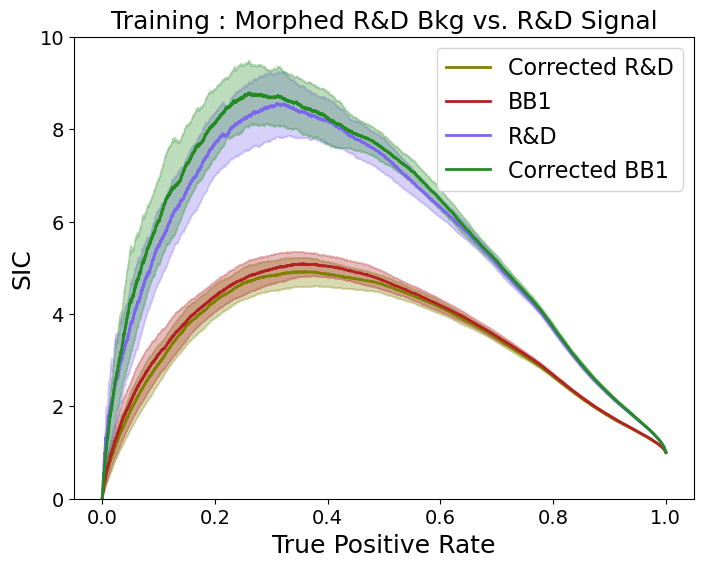

In [9]:
x = np.linspace(0,1,30000)
plt.figure(figsize=(8,6))

lw=2

smoothed = []
for i in range(len(sics)):
    smoothed.append(np.interp(x,tprs[i],sics[i]).reshape(-1,1))
smoothed = np.concatenate(smoothed,axis=1)
mean_sic = np.mean(smoothed,axis=1)
sd_sic = np.std(smoothed,axis=1)
plt.fill_between(x,mean_sic-sd_sic,mean_sic+sd_sic,color='olive',alpha=0.3,zorder=1)
plt.plot(x,mean_sic,color='olive',label="Corrected R&D",zorder=2,linewidth=lw)

smoothed = []
for i in range(len(sics)):
    smoothed.append(np.interp(x,tprs_b1[i],sics_b1[i]).reshape(-1,1))
smoothed = np.concatenate(smoothed,axis=1)
mean_sic = np.mean(smoothed,axis=1)
sd_sic = np.std(smoothed,axis=1)
plt.fill_between(x,mean_sic-sd_sic,mean_sic+sd_sic,color='firebrick',alpha=0.3,zorder=1)
plt.plot(x,mean_sic,color='firebrick',label="BB1",zorder=2,linewidth=lw)

smoothed = []
for i in range(len(sics)):
    smoothed.append(np.interp(x,tprs_rd[i],sics_rd[i]).reshape(-1,1))
smoothed = np.concatenate(smoothed,axis=1)
mean_sic = np.mean(smoothed,axis=1)
sd_sic = np.std(smoothed,axis=1)
plt.fill_between(x,mean_sic-sd_sic,mean_sic+sd_sic,color='mediumslateblue',alpha=0.3,zorder=1)
plt.plot(x,mean_sic,color='mediumslateblue',label="R&D",zorder=2,linewidth=lw)

smoothed = []
for i in range(len(sics)):
    smoothed.append(np.interp(x,tprs_corr_b1[i],sics_corr_b1[i]).reshape(-1,1))
smoothed = np.concatenate(smoothed,axis=1)
mean_sic = np.mean(smoothed,axis=1)
sd_sic = np.std(smoothed,axis=1)
plt.fill_between(x,mean_sic-sd_sic,mean_sic+sd_sic,color='forestgreen',alpha=0.3,zorder=1)
plt.plot(x,mean_sic,color='forestgreen',label="Corrected BB1",zorder=2,linewidth=lw)

plt.ylim([0,10])
plt.legend(loc='upper right',fontsize=16)
plt.xlabel('True Positive Rate',fontsize=18)
plt.ylabel('SIC',fontsize=18)
xt = plt.xticks(fontsize=14)
yt = plt.yticks(fontsize=14)
plt.title("Training : Morphed R&D Bkg vs. R&D Signal",fontsize=18)

plt.savefig(f"NF_models_QR_general/{model_dir}/NN_corr_rd_vs_rdSignal/sic_comparison_trainCorrRDvsRDSignal.pdf")

# Neural net : distinguish corrected BB1 from signal

Loss: 0.1969744861125946, p = 76: 100%|██████████| 1463/1463 [00:32<00:00, 44.57it/s]  


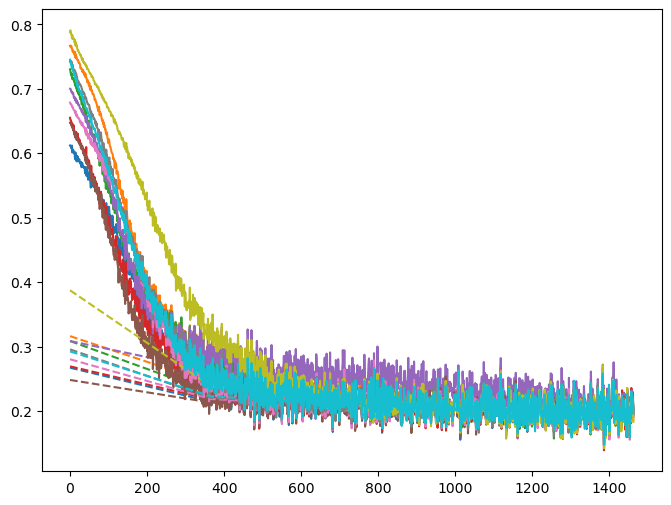

In [10]:
train = np.concatenate((corr_b1_train,rd_sig_train),axis=0)
train_lab = np.concatenate((np.zeros((corr_b1_train.shape[0],1)),np.ones((rd_sig_train.shape[0],1))),axis=0)
perm = np.random.permutation(train.shape[0])
train = train[perm]
train_lab = train_lab[perm]

test = np.concatenate((corr_b1_test,rd_sig_test),axis=0)
test_lab = np.concatenate((np.zeros((corr_b1_test.shape[0],1)),np.ones((rd_sig_test.shape[0],1))),axis=0)
perm = np.random.permutation(test.shape[0])
test = test[perm]
test_lab = test_lab[perm]

val = np.concatenate((corr_b1_val,rd_sig_val),axis=0)
val_lab = np.concatenate((np.zeros((corr_b1_val.shape[0],1)),np.ones((rd_sig_val.shape[0],1))),axis=0)
perm = np.random.permutation(val.shape[0])
val = val[perm]
val_lab = val_lab[perm]

mean = train.mean(axis=0)
sd = train.std(axis=0)
train = (train-mean)/sd
test = (test-mean)/sd
val = (val-mean)/sd

n_in = train.shape[1]
n_hidden = 16
num_hidden = 2
n_out = 1
act = nn.ReLU()
out_act = nn.Sigmoid()

n_iter = 10

plt.figure(figsize=(8,6))
if not os.path.isdir(f"NF_models_QR_general/{model_dir}/NN_corr_b1_vs_rdSignal/"):
    os.mkdir(f"NF_models_QR_general/{model_dir}/NN_corr_b1_vs_rdSignal/")
for i in range(n_iter):
    torch.manual_seed(np.random.randint(10000000,size=1)[0])
    net1 = qrnn.NeuralNet(n_in, n_hidden, n_out, num_hidden, act=act, out_act=out_act,dropout=0.1)
    net1,loss,val_loss = qrnn.train_nn(net1,train,train_lab,val,val_lab,n_epoch=5,lr=5e-4,bs=1024,lossfunc="BCE",plot=False,losses=True)
    plt.plot(np.arange(len(loss)),loss,color=f"C{i}")
    plt.plot(np.linspace(0,len(loss),len(val_loss)),val_loss,color=f"C{i}",linestyle='--')
    torch.save(net1,f"NF_models_QR_general/{model_dir}/NN_corr_b1_vs_rdSignal/training_{i}.pt")
    
    #net1 = torch.load(f"NF_models_QR_general/{model_dir}/NN_corr_b1_vs_rdSignal/training_{i}.pt")

# Test all the NN sig vs bkg models

In [38]:
test_bkg_samples = [b1_test,rd_test,corr_b1_test,corr_rd_test]
test_bkg_sampNames = ["BB1","R&D","Morphed BB1","Morphed R&D"]
test_bkg_colors = ["#B22222","#AC53AB","#53AC54","#22B2B2"]
test_sig_samples = [rd_sig_test,b1_sig]
test_sig_sampNames = ["R&D Signal","BB1 Signal"]
test_sig_sampNamesShort = ["RDSignal","BB1Signal"]
prefix = f"NF_models_QR_general/{model_dir}/"
models = ["NN_bb1_vs_rdSignal","NN_rd_vs_rdSignal","NN_corr_rd_vs_rdSignal","NN_corr_b1_vs_rdSignal"]
train_sets = [np.concatenate((b1_train,rd_sig_train),axis=0),np.concatenate((rd_train,rd_sig_train),axis=0),np.concatenate((corr_rd_train,rd_sig_train),axis=0),np.concatenate((corr_b1_train,rd_sig_train),axis=0)]
train_means = [t.mean(axis=0) for t in train_sets]
train_sds = [t.std(axis=0) for t in train_sets]
models_trainString = ["BB1 Bkg vs. R&D Signal","R&D Bkg vs. R&D Signal","Morphed R&D Bkg vs. R&D Signal","Morphed BB1 Bkg vs. R&D Signal"]

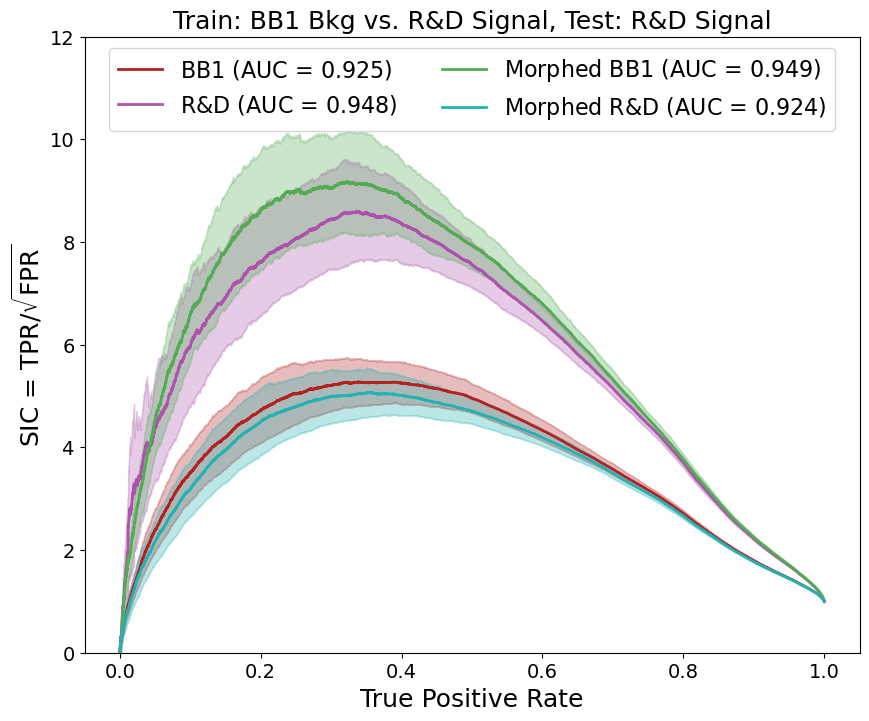

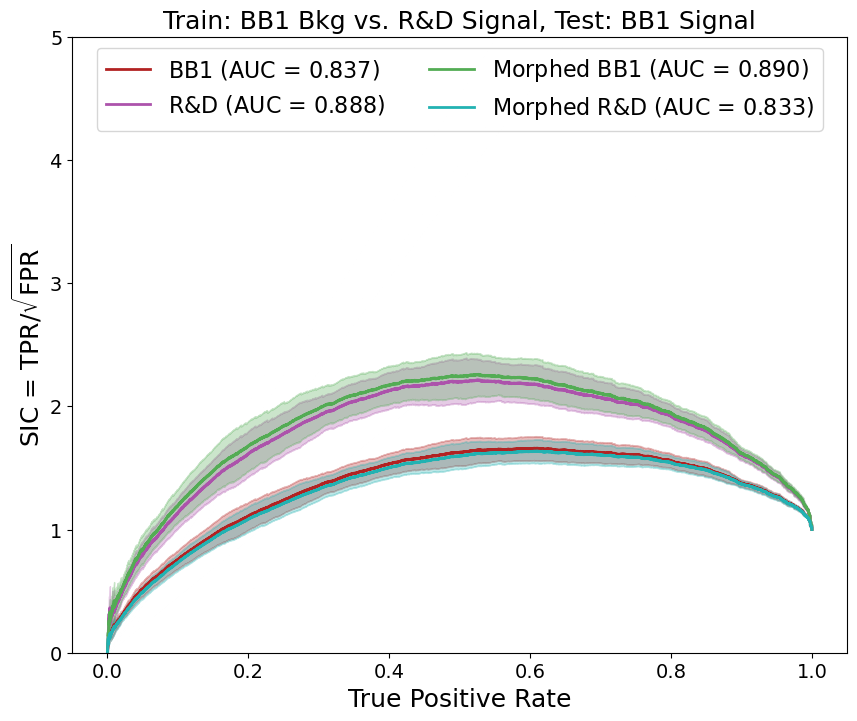

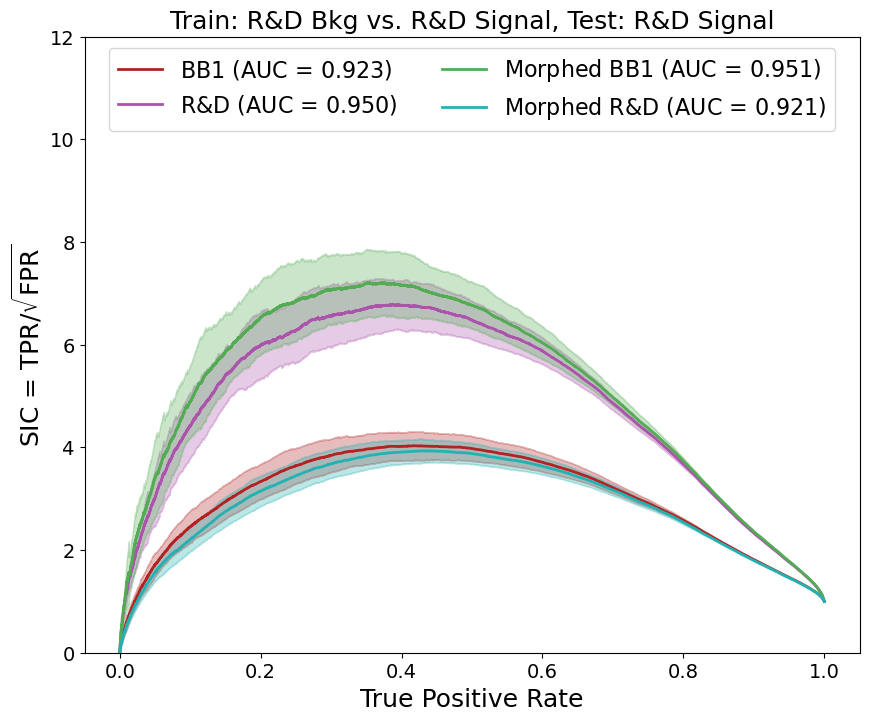

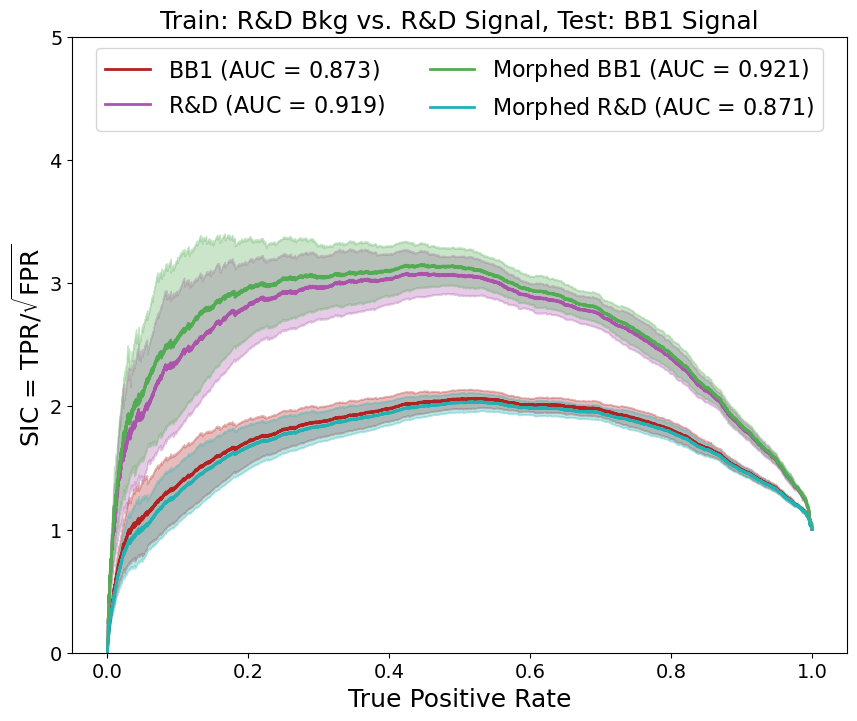

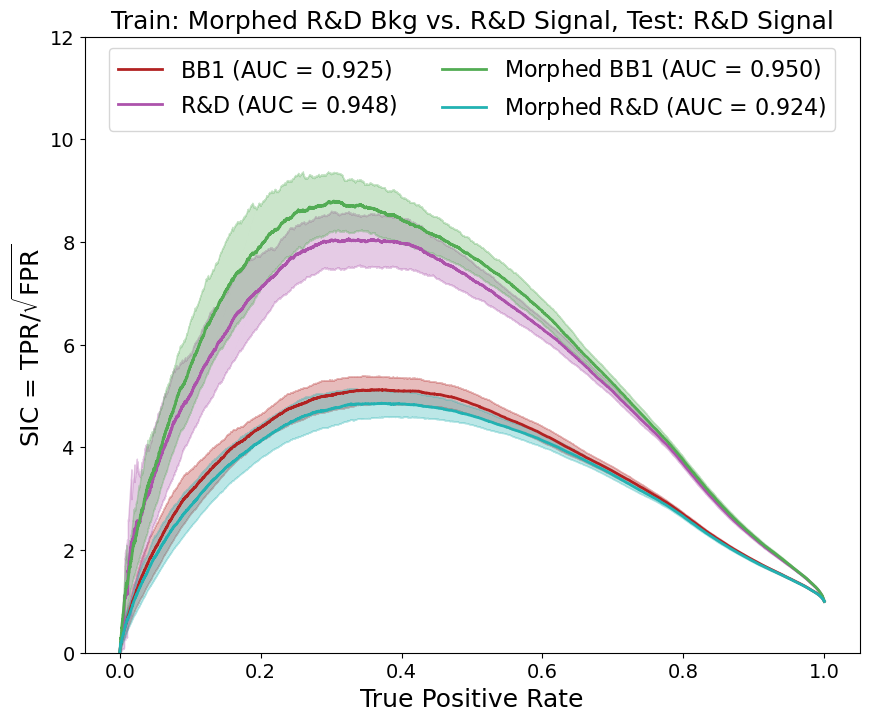

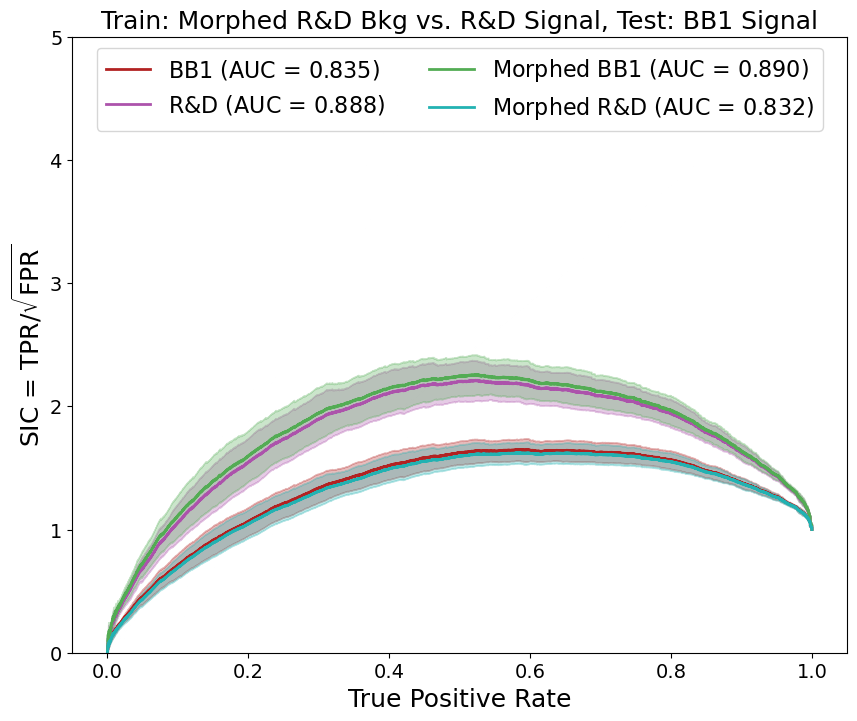

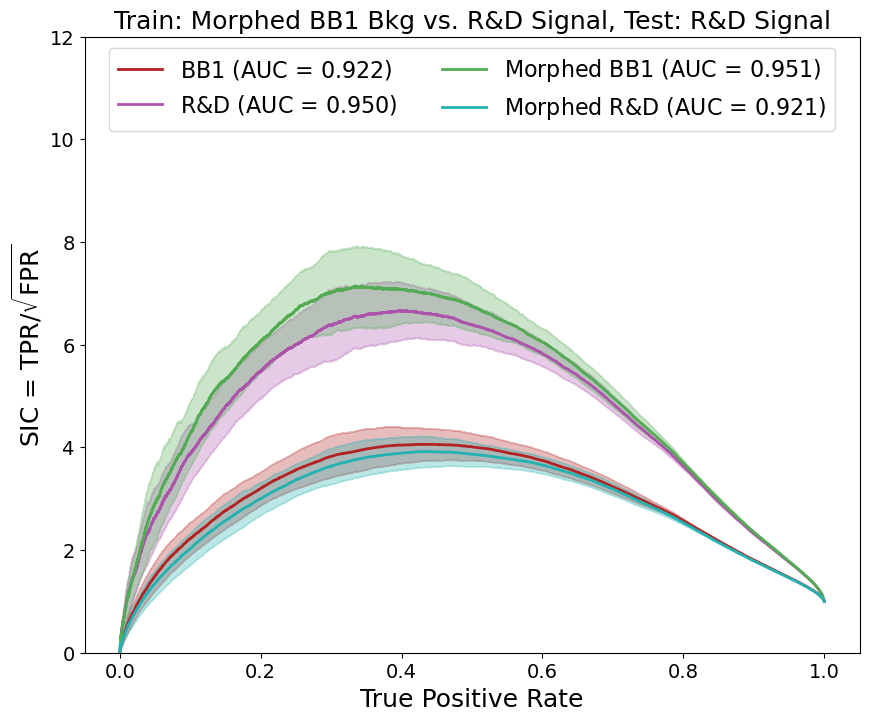

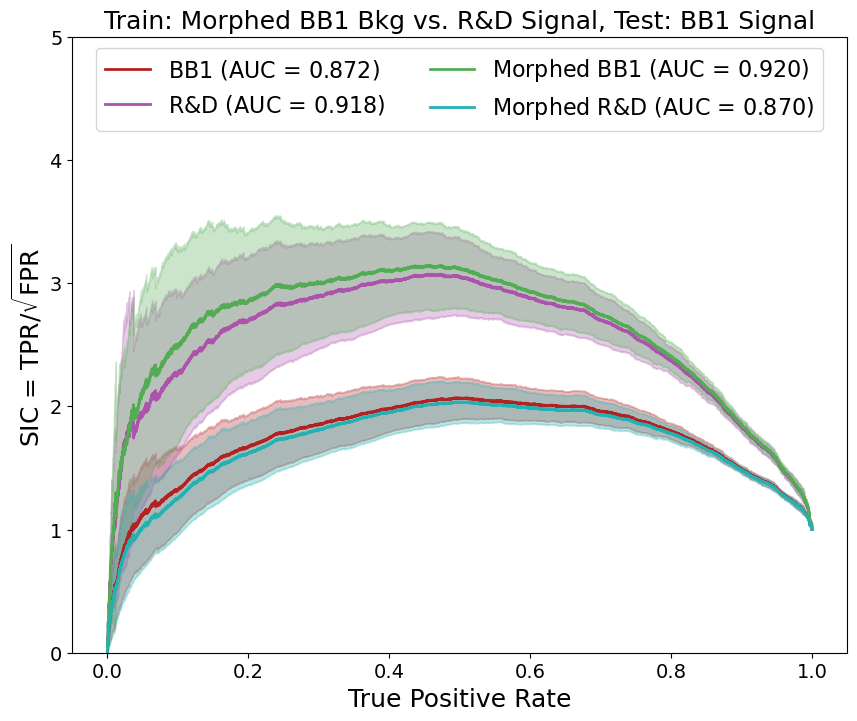

In [41]:
lw = 2 #line width
for mod,modString,train_mean,train_sd in zip(models,models_trainString,train_means,train_sds):
    for sig_samp, sig_name, sig_name_short in zip(test_sig_samples,test_sig_sampNames,test_sig_sampNamesShort):
        x = np.linspace(0,1,30000)
        plt.figure(figsize=(10,8))
        for bkg_samp, bkg_name, bkg_color in zip(test_bkg_samples,test_bkg_sampNames,test_bkg_colors):
            aucs = []
            tprs = []
            fprs = []
            sics = []
            for i in range(10):
                net = torch.load(f"{prefix}/{mod}/training_{i}.pt").to(device)
                inputs = np.concatenate((bkg_samp,sig_samp),axis=0)
                inputs = (inputs-train_mean)/train_sd
                labels = np.concatenate((np.zeros((bkg_samp.shape[0],1)),np.ones((sig_samp.shape[0],1))),axis=0)
                with torch.no_grad():
                    preds = net(torch.tensor(inputs,device=device,dtype=torch.float32)).cpu().numpy()
                aucs.append(roc_auc_score(labels,preds))
                fpr,tpr,thresh = roc_curve(labels,preds)
                tprs.append(tpr)
                fprs.append(fpr)
                sics.append(np.divide(tpr,np.sqrt(fpr),where=fpr>0))
                del inputs, labels, preds, net
                torch.cuda.empty_cache()
            smoothed = []
            for i in range(len(sics)):
                smoothed.append(np.interp(x,tprs[i],sics[i]).reshape(-1,1))
            smoothed = np.concatenate(smoothed,axis=1)
            mean_sic = np.mean(smoothed,axis=1)
            sd_sic = np.std(smoothed,axis=1)
            plt.fill_between(x,mean_sic-sd_sic,mean_sic+sd_sic,color=bkg_color,alpha=0.3,zorder=1)
            plt.plot(x,mean_sic,color=bkg_color,label=f"{bkg_name} (AUC = ${np.mean(aucs):.3f})$",zorder=2,linewidth=lw)
            plt.title(f"Train: {modString}, Test: {sig_name}",fontsize=18)
            if sig_name == "R&D Signal":
                plt.ylim([0,12])
            else:
                plt.ylim([0,5])

            plt.legend(loc='upper center',ncol=2,fontsize=16)
            plt.xlabel('True Positive Rate',fontsize=18)
            plt.ylabel('SIC = $\mathrm{TPR}/\sqrt{\mathrm{FPR}}$',fontsize=18)
            xt = plt.xticks(fontsize=14)
            yt = plt.yticks(fontsize=14)
            
            plt.savefig(f"{prefix}/{mod}/SICs_{mod}_inject{sig_name_short}.pdf")